# 1. Setup

Libraries and setting seed:

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm            # for OLS
from linearmodels import IV2SLS         # for 2SLS
from econml.grf import CausalForest     # for causal forest
import keras                            # for NNet
from econml.iv.dml import DMLIV         # for DML with IV
from econml.dml import LinearDML        # for DML
import xgboost as xgb                   # for DML first stage
import pickle                           # for storing and loading fitted models
from sklearn import preprocessing       # for standardizing covariates
import time
import os

%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (18, 12)

seed = 1000

np.random.seed(seed)

Importing the data and slight processing:

In [2]:
products = pd.read_csv('NL Estimation Set.csv')

# Keeping only 2012Q2 for faster runtime
products = products[products.uniquequarter == 2]
nrow = products.shape[0]

# Fuel cost per gallon of the product (distance-weighted when there are two different carriers)
products['prod_costpergallon'] = np.where(
    ~pd.isna(products.aptcode3),
    (products.costpergallon1 * products.distance1.astype("int") + products.costpergallon2 * products.distance2) / (products.distance1.astype("int") + products.distance2),
    products.costpergallon1
)

# Total product fuel cost approximation
products['total_fuel_approx'] = products.prod_costpergallon * products.market_miles_flown
# First and second segment fuel costs * distance
products['Xdistance_costpergallon1'] = products.distance1 * products.costpergallon1
products['Xdistance_costpergallon2'] = products.distance2 * products.costpergallon2

# Bunching all the LCCs besides Southwest into one group
products['ticket_carrier2'] = np.where((products.ticket_carrier == 'US') | (products.ticket_carrier == 'AA') | (products.ticket_carrier == 'UA') | (products.ticket_carrier == 'DL') | (products.ticket_carrier == 'WN'),
                                       products.ticket_carrier,
                                       'LCC')
# Log of within-nest share
products['ln_sjg'] = np.log(products.sjg)

# Converting the ticket carriers and quarters (for seasonality) into dummies, as well as origin and destination dummies
products = products.drop(columns = 'LCC')
products = pd.get_dummies(products,
                          columns = ['ticket_carrier2'],
                          prefix = [None],
                          drop_first = False)

# Converting boolean variables to integers
products['nonstop'] = products.nonstop.astype('int')
products['monopoly'] = products.monopoly.astype('int')

# Replacing nans with 0s (EconML's DML function doesn't support nans in the covariates for some reason, even though XGB allows
# them), and adding an indicator that they are nans
for var in ['avg_dist_rivals', 'prod_costpergallon', 'costpergallon1', 'costpergallon2', 'total_fuel_approx', 'Xdistance_costpergallon1', 'Xdistance_costpergallon2']:
    products[f'{var}_nan'] = np.isnan(products.prod_costpergallon).astype('int')
    products[f'{var}'] = products[f'{var}'].fillna(0)

Defining the outcome, treatments, covariates and excluded instruments:

In [3]:
y = np.log(products.sj / products.s0).to_numpy()
T = products[['price', 'ln_sjg']].to_numpy()
X = products[['nonstop', 'presence_origin', 'presence_dest', 'extra_miles', 'nonstop_miles',
              'popestimate1', 'popestimate2', 'DL', 'LCC', 'UA', 'US', 'WN']].to_numpy().astype('float')
Z = products[['LCC_presence', 'avg_dist_rivals', 'rival_num', 'monopoly', 'prod_costpergallon', 'costpergallon1',
              'costpergallon2', 'total_fuel_approx', 'Xdistance_costpergallon1', 'Xdistance_costpergallon2']
             + [col for col in products if col.endswith('_nan')]].to_numpy()

# 2. Estimation

Objects and directories for storing output:

In [4]:
ind = {}
dml1_l = []
dml2_l = []
grf_l  = []
mlp_l  = []

export_dir = f'Outputs'
try:
    os.mkdir(export_dir)
except:
    None

try:
    os.mkdir(export_dir + '\\Models')
except:
    None

Defining grids of points on the covariate space at which CATEs and marginal effects will be estimated:

In [5]:
med_vals = np.median(np.delete(X[X[:,0] == 0, 1:7], 2, 1), axis = 0)
AA_grid_grf  = np.array([np.hstack((0, med_vals[:2], d, med_vals[3:], 0, 0, 0, 0, 0)) for d in np.arange(300, 2501, 10)])
DL_grid_grf  = np.array([np.hstack((0, med_vals[:2], d, med_vals[3:], 1, 0, 0, 0, 0)) for d in np.arange(300, 2501, 10)])
LCC_grid_grf = np.array([np.hstack((0, med_vals[:2], d, med_vals[3:], 0, 1, 0, 0, 0)) for d in np.arange(300, 2501, 10)])
UA_grid_grf  = np.array([np.hstack((0, med_vals[:2], d, med_vals[3:], 0, 0, 1, 0, 0)) for d in np.arange(300, 2501, 10)])
US_grid_grf  = np.array([np.hstack((0, med_vals[:2], d, med_vals[3:], 0, 0, 0, 1, 0)) for d in np.arange(300, 2501, 10)])
WN_grid_grf  = np.array([np.hstack((0, med_vals[:2], d, med_vals[3:], 0, 0, 0, 0, 1)) for d in np.arange(300, 2501, 10)])
AA_ests_grf  = []
DL_ests_grf  = []
LCC_ests_grf = []
UA_ests_grf  = []
US_ests_grf  = []
WN_ests_grf  = []


med_vals = np.median(X[X[:,0] == 0, 1:7], axis = 0)
AA_grid1_mlp  = np.array([np.hstack((0, med_vals[:2], d, e, med_vals[4:], 0, 0, 0, 0, 0)) for d in np.arange(300, 2401, 700) for e in np.arange(1.01,2,0.05)])
DL_grid1_mlp  = np.array([np.hstack((0, med_vals[:2], d, e, med_vals[4:], 1, 0, 0, 0, 0)) for d in np.arange(300, 2401, 700) for e in np.arange(1.01,2,0.05)])
LCC_grid1_mlp = np.array([np.hstack((0, med_vals[:2], d, e, med_vals[4:], 0, 1, 0, 0, 0)) for d in np.arange(300, 2401, 700) for e in np.arange(1.01,2,0.05)])
UA_grid1_mlp  = np.array([np.hstack((0, med_vals[:2], d, e, med_vals[4:], 0, 0, 1, 0, 0)) for d in np.arange(300, 2401, 700) for e in np.arange(1.01,2,0.05)])
US_grid1_mlp  = np.array([np.hstack((0, med_vals[:2], d, e, med_vals[4:], 0, 0, 0, 1, 0)) for d in np.arange(300, 2401, 700) for e in np.arange(1.01,2,0.05)])
WN_grid1_mlp  = np.array([np.hstack((0, med_vals[:2], d, e, med_vals[4:], 0, 0, 0, 0, 1)) for d in np.arange(300, 2401, 700) for e in np.arange(1.01,2,0.05)])
AA_grid2_mlp  = np.array([np.hstack((0, med_vals[:2], d, e, med_vals[4:], 0, 0, 0, 0, 0)) for d in np.arange(300, 2401, 700) for e in np.arange(1.01,2,0.05) + 0.1])
DL_grid2_mlp  = np.array([np.hstack((0, med_vals[:2], d, e, med_vals[4:], 1, 0, 0, 0, 0)) for d in np.arange(300, 2401, 700) for e in np.arange(1.01,2,0.05) + 0.1])
LCC_grid2_mlp = np.array([np.hstack((0, med_vals[:2], d, e, med_vals[4:], 0, 1, 0, 0, 0)) for d in np.arange(300, 2401, 700) for e in np.arange(1.01,2,0.05) + 0.1])
UA_grid2_mlp  = np.array([np.hstack((0, med_vals[:2], d, e, med_vals[4:], 0, 0, 1, 0, 0)) for d in np.arange(300, 2401, 700) for e in np.arange(1.01,2,0.05) + 0.1])
US_grid2_mlp  = np.array([np.hstack((0, med_vals[:2], d, e, med_vals[4:], 0, 0, 0, 1, 0)) for d in np.arange(300, 2401, 700) for e in np.arange(1.01,2,0.05) + 0.1])
WN_grid2_mlp  = np.array([np.hstack((0, med_vals[:2], d, e, med_vals[4:], 0, 0, 0, 0, 1)) for d in np.arange(300, 2401, 700) for e in np.arange(1.01,2,0.05) + 0.1])
AA_ests_mlp  = []
DL_ests_mlp  = []
LCC_ests_mlp = []
UA_ests_mlp  = []
US_ests_mlp  = []
WN_ests_mlp  = []

1000 bootstrap iterations of the first and second step estimations (ultimately stopped after 800):


3/3 [==============================] - 0s 997us/step
(40.1) | Iteration time: 247.4

3/3 [==============================] - 0s 1ms/step
(17.9) | Iteration time: 226.4

3/3 [==============================] - 0s 1ms/step
(25.9) | Iteration time: 235.5

3/3 [==============================] - 0s 1ms/step
(37.5) | Iteration time: 248.6

3/3 [==============================] - 0s 998us/step
(30.8) | Iteration time: 240.2

3/3 [==============================] - 0s 997us/step
(37.6) | Iteration time: 247.7

3/3 [==============================] - 0s 1ms/step
(43.8) | Iteration time: 254.4

3/3 [==============================] - 0s 1ms/step
(41.6) | Iteration time: 252.2

3/3 [==============================] - 0s 1ms/step
(18.8) | Iteration time: 233.9

3/3 [==============================] - 0s 1ms/step
(50.7) | Iteration time: 265.0

3/3 [==============================] - 0s 999us/step
(61.4) | Iteration time: 275.9

3/3 [==============================] - 0s 1ms/step


3/3 [==============================] - 0s 997us/step
(41.1) | Iteration time: 253.9

3/3 [==============================] - 0s 1ms/step
(43.5) | Iteration time: 256.4

3/3 [==============================] - 0s 1ms/step
(27.3) | Iteration time: 244.1

3/3 [==============================] - 0s 998us/step
(57.4) | Iteration time: 272.7

3/3 [==============================] - 0s 1ms/step
(46.3) | Iteration time: 260.6

3/3 [==============================] - 0s 993us/step
(31.8) | Iteration time: 246.6

3/3 [==============================] - 0s 998us/step
(30.4) | Iteration time: 248.8

3/3 [==============================] - 0s 999us/step
(35.6) | Iteration time: 252.0

3/3 [==============================] - 0s 998us/step
(63.6) | Iteration time: 278.9

3/3 [==============================] - 0s 998us/step
(56.0) | Iteration time: 270.8

3/3 [==============================] - 0s 2ms/step
(39.0) | Iteration time: 254.0

3/3 [==============================] - 0s 999us/step
(53.7) | Iteration t

3/3 [==============================] - 0s 999us/step
(42.9) | Iteration time: 259.0

3/3 [==============================] - 0s 1ms/step
(33.1) | Iteration time: 250.3

3/3 [==============================] - 0s 1ms/step
(90.3) | Iteration time: 312.8

3/3 [==============================] - 0s 1ms/step
(20.8) | Iteration time: 238.3

3/3 [==============================] - 0s 1ms/step
(31.6) | Iteration time: 250.3

3/3 [==============================] - 0s 1ms/step
(40.5) | Iteration time: 258.1

3/3 [==============================] - 0s 1ms/step
(64.8) | Iteration time: 282.8

3/3 [==============================] - 0s 1ms/step
(42.8) | Iteration time: 265.3

3/3 [==============================] - 0s 1ms/step
(28.6) | Iteration time: 248.5

3/3 [==============================] - 0s 998us/step
(63.9) | Iteration time: 282.4

3/3 [==============================] - 0s 998us/step
(47.5) | Iteration time: 265.9

3/3 [==============================] - 0s 1ms/step
(64.9) | Iteration time: 283.0

3/3 [==============================] - 0s 2ms/step
(34.6) | Iteration time: 256.9

3/3 [==============================] - 0s 1ms/step
(86.9) | Iteration time: 309.3

3/3 [==============================] - 0s 8ms/step
(35.3) | Iteration time: 257.4

3/3 [==============================] - 0s 1ms/step
(57.6) | Iteration time: 279.3

3/3 [==============================] - 0s 1ms/step
(91.8) | Iteration time: 318.4

3/3 [==============================] - 0s 1ms/step
(72.0) | Iteration time: 297.2

3/3 [==============================] - 0s 1ms/step
(70.3) | Iteration time: 292.2

3/3 [==============================] - 0s 0s/step
(43.2) | Iteration time: 264.7

3/3 [==============================] - 0s 1ms/step
(53.6) | Iteration time: 276.5

3/3 [==============================] - 0s 1ms/step
(33.1) | Iteration time: 259.9

3/3 [==============================] - 0s 1ms/step
(51.3) | Iteration time: 275.2

3/3 [==============================] - 0s 1ms/step
(55.1) | Iteration time: 278.0

3/3 [

3/3 [==============================] - 0s 2ms/step
(54.5) | Iteration time: 280.4

3/3 [==============================] - 0s 2ms/step
(41.2) | Iteration time: 269.0

3/3 [==============================] - 0s 0s/step
(64.6) | Iteration time: 300.0

3/3 [==============================] - 0s 0s/step
(60.2) | Iteration time: 286.6

3/3 [==============================] - 0s 0s/step
(35.6) | Iteration time: 259.7

3/3 [==============================] - 0s 8ms/step
(72.5) | Iteration time: 297.0

3/3 [==============================] - 0s 0s/step
(62.1) | Iteration time: 291.0

3/3 [==============================] - 0s 0s/step
(84.2) | Iteration time: 308.8

3/3 [==============================] - 0s 0s/step
(64.7) | Iteration time: 288.8

3/3 [==============================] - 0s 0s/step
(75.1) | Iteration time: 299.3

3/3 [==============================] - 0s 0s/step
(57.3) | Iteration time: 282.0

3/3 [==============================] - 0s 0s/step
(54.2) | Iteration time: 283.1

3/3 [========

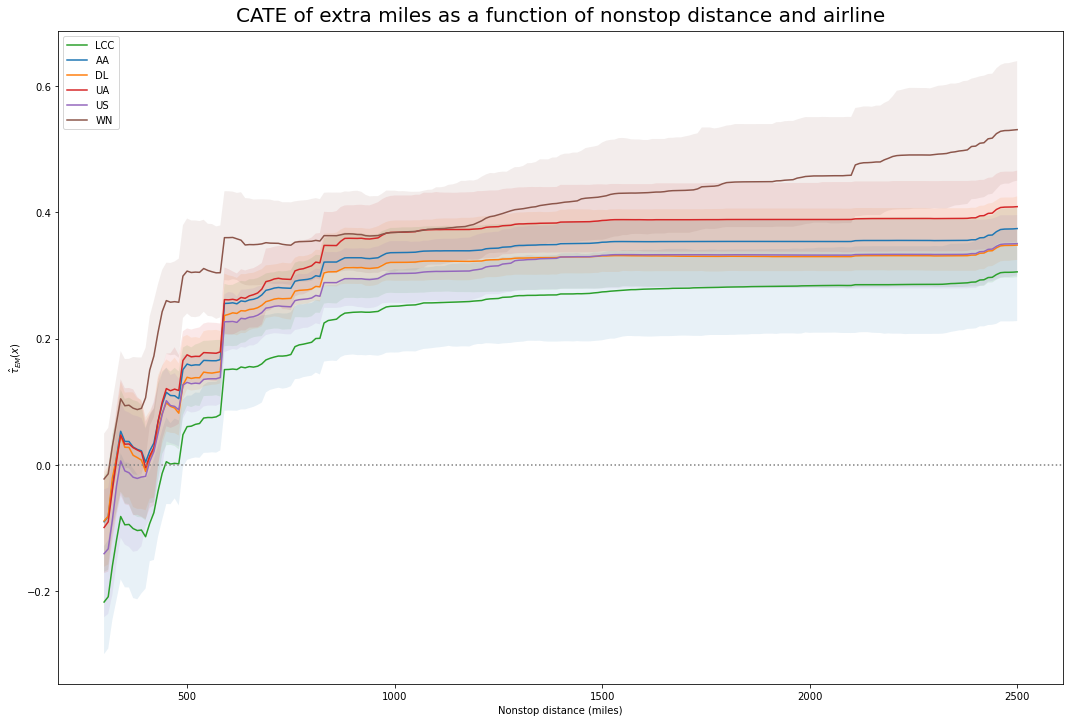


3/3 [==============================] - 0s 0s/step
(81.6) | Iteration time: 313.1

3/3 [==============================] - 0s 0s/step
(52.1) | Iteration time: 282.3

3/3 [==============================] - 0s 8ms/step
(52.0) | Iteration time: 278.9

3/3 [==============================] - 0s 0s/step
(27.4) | Iteration time: 256.6

3/3 [==============================] - 0s 8ms/step
(58.1) | Iteration time: 284.4

3/3 [==============================] - 0s 0s/step
(76.8) | Iteration time: 302.1

3/3 [==============================] - 0s 0s/step
(56.2) | Iteration time: 282.6

3/3 [==============================] - 0s 0s/step
(54.7) | Iteration time: 280.1

3/3 [==============================] - 0s 0s/step
(93.7) | Iteration time: 324.8

3/3 [==============================] - 0s 0s/step
(76.2) | Iteration time: 303.8

3/3 [==============================] - 0s 0s/step
(47.6) | Iteration time: 274.2

3/3 [==============================] - 0s 0s/step
(67.0) | Iteration time: 292.9

3/3 [========

3/3 [==============================] - 0s 0s/step
(51.6) | Iteration time: 283.5

3/3 [==============================] - 0s 8ms/step
(36.6) | Iteration time: 266.5

3/3 [==============================] - 0s 0s/step
(36.6) | Iteration time: 265.4

3/3 [==============================] - 0s 0s/step
(57.4) | Iteration time: 285.9

3/3 [==============================] - 0s 0s/step
(36.8) | Iteration time: 264.5

3/3 [==============================] - 0s 0s/step
(36.5) | Iteration time: 265.8

3/3 [==============================] - 0s 0s/step
(48.1) | Iteration time: 276.0

3/3 [==============================] - 0s 8ms/step
(51.8) | Iteration time: 279.5

3/3 [==============================] - 0s 8ms/step
(60.0) | Iteration time: 287.2

3/3 [==============================] - 0s 0s/step
(52.7) | Iteration time: 278.5

3/3 [==============================] - 0s 0s/step
(60.1) | Iteration time: 292.4

3/3 [==============================] - 0s 1ms/step
(36.2) | Iteration time: 266.7

3/3 [=======

3/3 [==============================] - 0s 1ms/step
(57.8) | Iteration time: 286.7

3/3 [==============================] - 0s 1ms/step
(35.4) | Iteration time: 273.8

3/3 [==============================] - 0s 1ms/step
(56.3) | Iteration time: 289.3

3/3 [==============================] - 0s 1ms/step
(64.0) | Iteration time: 296.9

3/3 [==============================] - 0s 2ms/step
(37.5) | Iteration time: 269.4

3/3 [==============================] - 0s 1ms/step
(72.4) | Iteration time: 303.7

3/3 [==============================] - 0s 2ms/step
(44.1) | Iteration time: 282.4

3/3 [==============================] - 0s 1ms/step
(51.2) | Iteration time: 284.2

3/3 [==============================] - 0s 2ms/step
(88.5) | Iteration time: 321.2

3/3 [==============================] - 0s 1ms/step
(85.3) | Iteration time: 317.4

3/3 [==============================] - 0s 997us/step
(50.8) | Iteration time: 282.3

3/3 [==============================] - 0s 1ms/step
(43.3) | Iteration time: 279.2

3/

3/3 [==============================] - 0s 2ms/step
(50.5) | Iteration time: 284.0

3/3 [==============================] - 0s 998us/step
(54.8) | Iteration time: 289.5

3/3 [==============================] - 0s 2ms/step
(47.1) | Iteration time: 279.9

3/3 [==============================] - 0s 1ms/step
(25.0) | Iteration time: 261.8

3/3 [==============================] - 0s 1ms/step
(49.6) | Iteration time: 282.6

3/3 [==============================] - 0s 998us/step
(28.3) | Iteration time: 261.8

3/3 [==============================] - 0s 1ms/step
(40.7) | Iteration time: 273.9

3/3 [==============================] - 0s 1ms/step
(72.1) | Iteration time: 304.7

3/3 [==============================] - 0s 2ms/step
(39.1) | Iteration time: 278.5

3/3 [==============================] - 0s 2ms/step
(50.9) | Iteration time: 285.6

3/3 [==============================] - 0s 1ms/step
(62.2) | Iteration time: 297.1

3/3 [==============================] - 0s 1ms/step
(70.9) | Iteration time: 306.0



3/3 [==============================] - 0s 2ms/step
(45.3) | Iteration time: 280.4

3/3 [==============================] - 0s 2ms/step
(27.2) | Iteration time: 271.5

3/3 [==============================] - 0s 1ms/step
(69.2) | Iteration time: 308.8

3/3 [==============================] - 0s 1ms/step
(44.0) | Iteration time: 286.1

3/3 [==============================] - 0s 1ms/step
(30.9) | Iteration time: 271.6

3/3 [==============================] - 0s 2ms/step
(80.9) | Iteration time: 321.9

3/3 [==============================] - 0s 2ms/step
(45.3) | Iteration time: 287.8


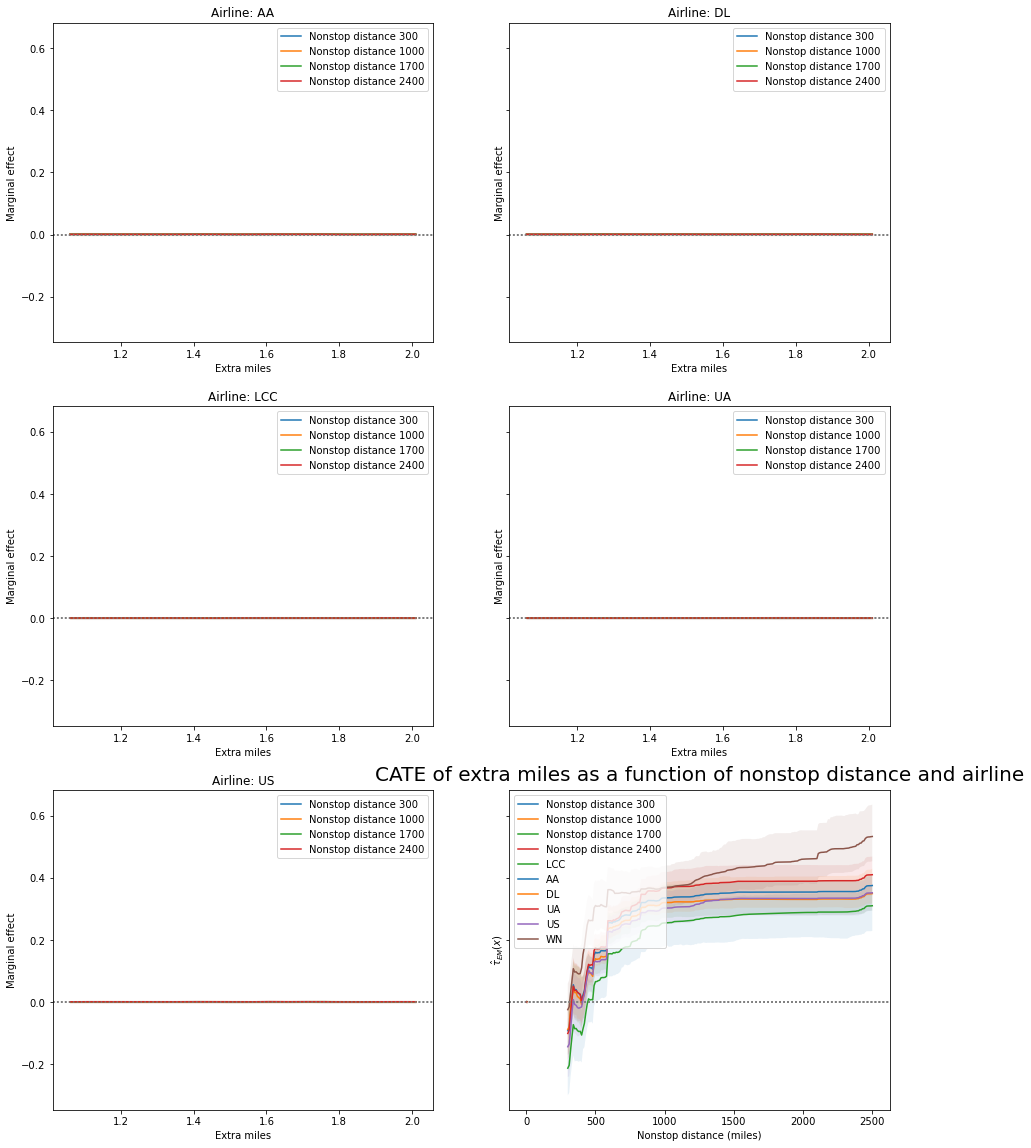


3/3 [==============================] - 0s 2ms/step
(58.2) | Iteration time: 299.9

3/3 [==============================] - 0s 2ms/step
(38.6) | Iteration time: 277.1

3/3 [==============================] - 0s 1ms/step
(97.5) | Iteration time: 339.6

3/3 [==============================] - 0s 1ms/step
(25.4) | Iteration time: 262.5

3/3 [==============================] - 0s 1ms/step
(60.4) | Iteration time: 299.4

3/3 [==============================] - 0s 2ms/step
(54.2) | Iteration time: 291.1

3/3 [==============================] - 0s 1ms/step
(40.2) | Iteration time: 277.3

3/3 [==============================] - 0s 1ms/step
(80.3) | Iteration time: 327.3

3/3 [==============================] - 0s 1ms/step
(70.6) | Iteration time: 311.3

3/3 [==============================] - 0s 1ms/step
(64.6) | Iteration time: 305.3

3/3 [==============================] - 0s 1ms/step
(40.9) | Iteration time: 283.0

3/3 [==============================] - 0s 2ms/step
(55.0) | Iteration time: 296.3

3/3

3/3 [==============================] - 0s 2ms/step
(39.1) | Iteration time: 278.9

3/3 [==============================] - 0s 1ms/step
(47.9) | Iteration time: 287.9

3/3 [==============================] - 0s 1ms/step
(52.0) | Iteration time: 293.4

3/3 [==============================] - 0s 2ms/step
(29.5) | Iteration time: 269.6

3/3 [==============================] - 0s 1ms/step
(26.1) | Iteration time: 274.0

3/3 [==============================] - 0s 1ms/step
(48.0) | Iteration time: 288.7

3/3 [==============================] - 0s 1ms/step
(106.7) | Iteration time: 347.2

3/3 [==============================] - 0s 1ms/step
(65.1) | Iteration time: 306.5

3/3 [==============================] - 0s 1ms/step
(52.1) | Iteration time: 289.9

3/3 [==============================] - 0s 2ms/step
(79.4) | Iteration time: 325.9

3/3 [==============================] - 0s 2ms/step
(53.8) | Iteration time: 296.0

3/3 [==============================] - 0s 1ms/step
(43.9) | Iteration time: 288.2

3/3

3/3 [==============================] - 0s 2ms/step
(53.7) | Iteration time: 293.1

3/3 [==============================] - 0s 1ms/step
(45.0) | Iteration time: 292.3

3/3 [==============================] - 0s 2ms/step
(64.1) | Iteration time: 306.3

3/3 [==============================] - 0s 1ms/step
(57.2) | Iteration time: 301.8

3/3 [==============================] - 0s 2ms/step
(69.8) | Iteration time: 311.2

3/3 [==============================] - 0s 2ms/step
(48.6) | Iteration time: 289.1

3/3 [==============================] - 0s 2ms/step
(78.5) | Iteration time: 328.3

3/3 [==============================] - 0s 2ms/step
(79.4) | Iteration time: 321.4

3/3 [==============================] - 0s 2ms/step
(58.7) | Iteration time: 304.4

3/3 [==============================] - 0s 2ms/step
(35.0) | Iteration time: 279.3

3/3 [==============================] - 0s 1ms/step
(40.6) | Iteration time: 285.0

3/3 [==============================] - 0s 2ms/step
(45.9) | Iteration time: 297.4

3/3 

3/3 [==============================] - 0s 2ms/step
(65.5) | Iteration time: 313.6

3/3 [==============================] - 0s 2ms/step
(31.0) | Iteration time: 277.0

3/3 [==============================] - 0s 2ms/step
(26.5) | Iteration time: 273.2

3/3 [==============================] - 0s 2ms/step
(27.5) | Iteration time: 282.3

3/3 [==============================] - 0s 1ms/step
(61.3) | Iteration time: 310.3

3/3 [==============================] - 0s 1ms/step
(45.0) | Iteration time: 292.1

3/3 [==============================] - 0s 2ms/step
(76.8) | Iteration time: 324.7

3/3 [==============================] - 0s 1ms/step
(67.5) | Iteration time: 313.0

3/3 [==============================] - 0s 2ms/step
(62.8) | Iteration time: 318.8

3/3 [==============================] - 0s 2ms/step
(61.0) | Iteration time: 309.6

3/3 [==============================] - 0s 1ms/step
(40.5) | Iteration time: 290.3

3/3 [==============================] - 0s 1ms/step
(111.0) | Iteration time: 358.3

3/3

3/3 [==============================] - 0s 3ms/step
(48.5) | Iteration time: 307.7

3/3 [==============================] - 0s 2ms/step
(48.0) | Iteration time: 301.6

3/3 [==============================] - 0s 2ms/step
(82.3) | Iteration time: 336.4

3/3 [==============================] - 0s 2ms/step
(41.4) | Iteration time: 297.5

3/3 [==============================] - 0s 1ms/step
(41.5) | Iteration time: 295.2

3/3 [==============================] - 0s 2ms/step
(67.4) | Iteration time: 330.7

3/3 [==============================] - 0s 2ms/step
(38.3) | Iteration time: 292.3


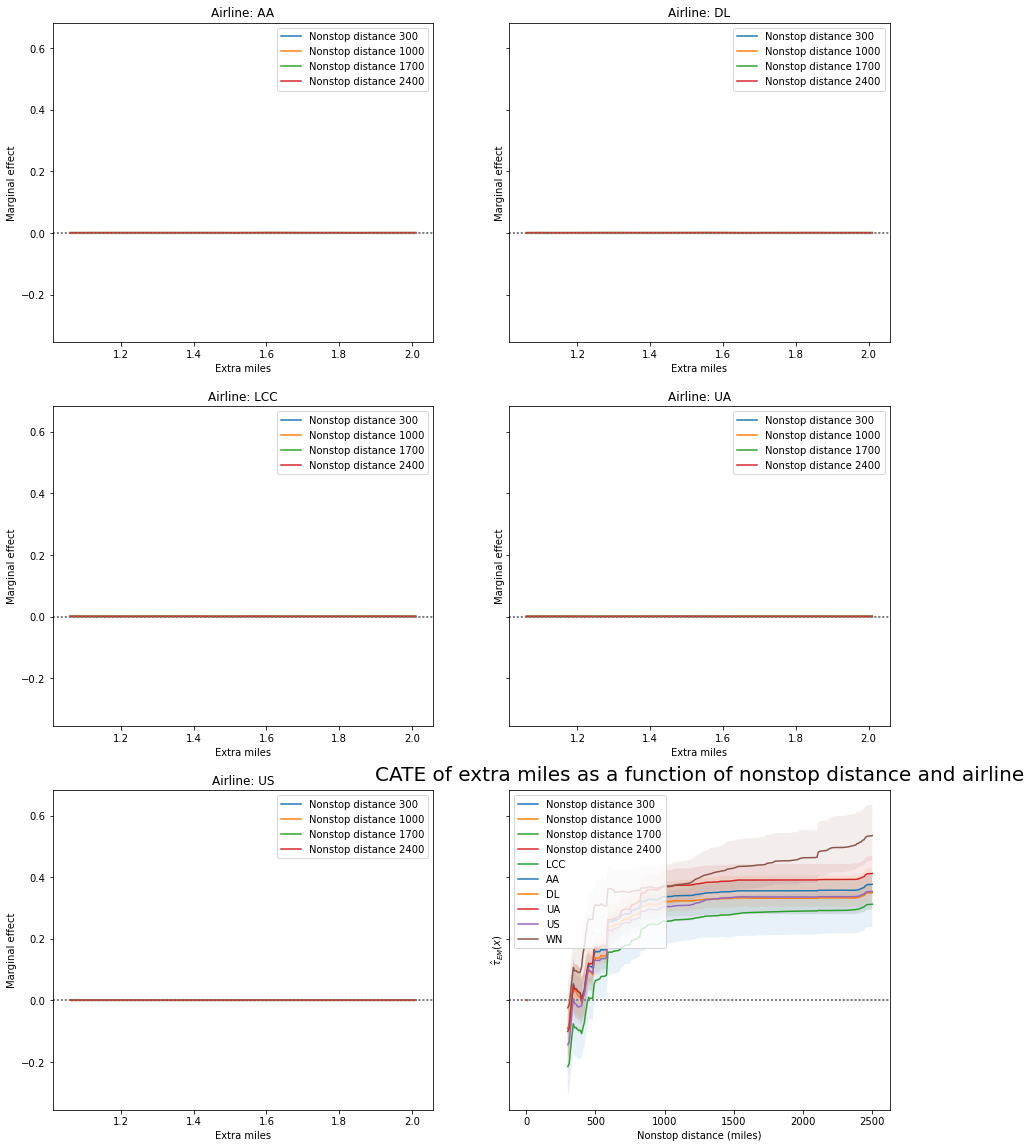


3/3 [==============================] - 0s 2ms/step
(51.5) | Iteration time: 309.7

3/3 [==============================] - 0s 2ms/step
(36.3) | Iteration time: 288.6

3/3 [==============================] - 0s 3ms/step
(58.9) | Iteration time: 316.2

3/3 [==============================] - 0s 2ms/step
(89.2) | Iteration time: 343.2

3/3 [==============================] - 0s 2ms/step
(59.5) | Iteration time: 315.7

3/3 [==============================] - 0s 1ms/step
(62.8) | Iteration time: 317.8

3/3 [==============================] - 0s 2ms/step
(28.4) | Iteration time: 282.4

3/3 [==============================] - 0s 0s/step
(54.7) | Iteration time: 321.7

3/3 [==============================] - 0s 0s/step
(33.0) | Iteration time: 286.2

3/3 [==============================] - 0s 0s/step
(91.2) | Iteration time: 345.0

3/3 [==============================] - 0s 0s/step
(70.1) | Iteration time: 322.6

3/3 [==============================] - 0s 0s/step
(45.1) | Iteration time: 296.0

3/3 [===

3/3 [==============================] - 0s 8ms/step
(110.9) | Iteration time: 370.0

3/3 [==============================] - 0s 8ms/step
(72.7) | Iteration time: 329.2

3/3 [==============================] - 0s 0s/step
(116.6) | Iteration time: 374.0

3/3 [==============================] - 0s 0s/step
(32.5) | Iteration time: 287.8

3/3 [==============================] - 0s 0s/step
(34.2) | Iteration time: 301.2

3/3 [==============================] - 0s 0s/step
(38.1) | Iteration time: 297.0

3/3 [==============================] - 0s 0s/step
(77.9) | Iteration time: 336.7

3/3 [==============================] - 0s 8ms/step
(36.6) | Iteration time: 293.1

3/3 [==============================] - 0s 0s/step
(105.0) | Iteration time: 359.8

3/3 [==============================] - 0s 0s/step
(43.6) | Iteration time: 297.3

3/3 [==============================] - 0s 0s/step
(54.8) | Iteration time: 320.3

3/3 [==============================] - 0s 0s/step
(59.8) | Iteration time: 321.2

3/3 [=====

3/3 [==============================] - 0s 0s/step
(43.4) | Iteration time: 305.2

3/3 [==============================] - 0s 8ms/step
(61.9) | Iteration time: 332.6

3/3 [==============================] - 0s 0s/step
(66.8) | Iteration time: 329.7

3/3 [==============================] - 0s 8ms/step
(39.1) | Iteration time: 303.1

3/3 [==============================] - 0s 8ms/step
(34.8) | Iteration time: 302.8

3/3 [==============================] - 0s 8ms/step
(54.6) | Iteration time: 321.1

3/3 [==============================] - 0s 8ms/step
(51.0) | Iteration time: 322.1

3/3 [==============================] - 0s 0s/step
(82.9) | Iteration time: 346.3

3/3 [==============================] - 0s 0s/step
(81.5) | Iteration time: 345.9

3/3 [==============================] - 0s 0s/step
(69.8) | Iteration time: 337.7

3/3 [==============================] - 0s 8ms/step
(53.8) | Iteration time: 314.5

3/3 [==============================] - 0s 0s/step
(78.7) | Iteration time: 340.7

3/3 [=====

3/3 [==============================] - 0s 0s/step
(40.1) | Iteration time: 307.5

3/3 [==============================] - 0s 8ms/step
(71.1) | Iteration time: 341.2

3/3 [==============================] - 0s 0s/step
(50.0) | Iteration time: 318.1

3/3 [==============================] - 0s 8ms/step
(66.3) | Iteration time: 331.5

3/3 [==============================] - 0s 0s/step
(87.6) | Iteration time: 362.0

3/3 [==============================] - 0s 8ms/step
(72.2) | Iteration time: 339.0

3/3 [==============================] - 0s 0s/step
(57.4) | Iteration time: 323.5

3/3 [==============================] - 0s 0s/step
(57.8) | Iteration time: 339.7

3/3 [==============================] - 0s 0s/step
(29.3) | Iteration time: 296.3

3/3 [==============================] - 0s 0s/step
(39.8) | Iteration time: 317.2

3/3 [==============================] - 0s 8ms/step
(46.1) | Iteration time: 313.8

3/3 [==============================] - 0s 0s/step
(43.7) | Iteration time: 310.9

3/3 [=======

3/3 [==============================] - 0s 8ms/step
(67.2) | Iteration time: 341.0

3/3 [==============================] - 0s 8ms/step
(99.0) | Iteration time: 375.5

3/3 [==============================] - 0s 0s/step
(131.0) | Iteration time: 401.4

3/3 [==============================] - 0s 8ms/step
(68.4) | Iteration time: 342.3

3/3 [==============================] - 0s 0s/step
(77.4) | Iteration time: 350.2

3/3 [==============================] - 0s 8ms/step
(40.8) | Iteration time: 314.6


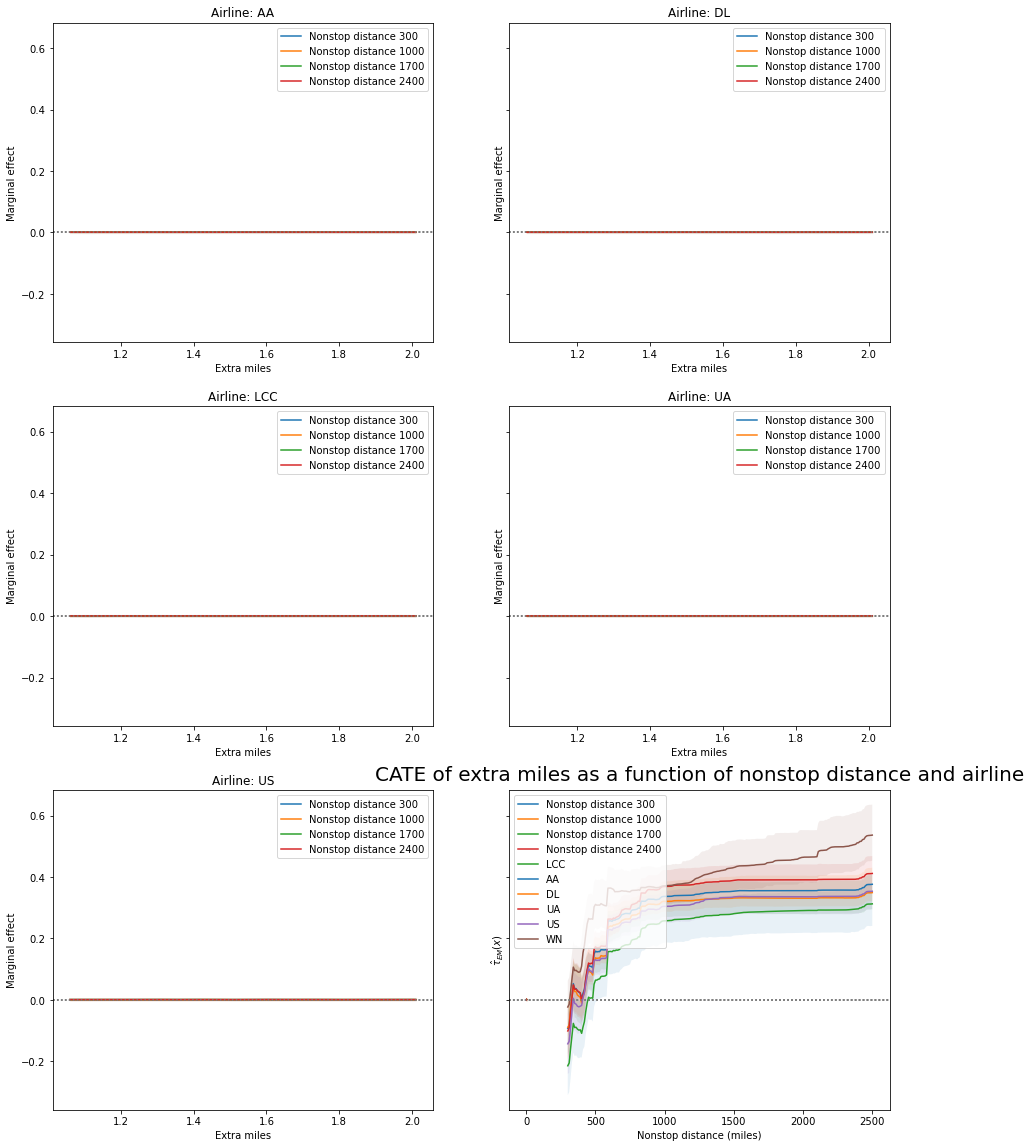


3/3 [==============================] - 0s 8ms/step
(108.8) | Iteration time: 391.9

3/3 [==============================] - 0s 8ms/step
(101.3) | Iteration time: 375.1

3/3 [==============================] - 0s 0s/step
(35.0) | Iteration time: 312.5

3/3 [==============================] - 0s 0s/step
(53.5) | Iteration time: 333.8

3/3 [==============================] - 0s 8ms/step
(51.7) | Iteration time: 322.8

3/3 [==============================] - 0s 8ms/step
(84.9) | Iteration time: 357.7

3/3 [==============================] - 0s 0s/step
(78.7) | Iteration time: 349.7

3/3 [==============================] - 0s 0s/step
(98.2) | Iteration time: 366.6

3/3 [==============================] - 0s 0s/step
(57.4) | Iteration time: 324.6

3/3 [==============================] - 0s 0s/step
(41.7) | Iteration time: 322.3

3/3 [==============================] - 0s 0s/step
(75.9) | Iteration time: 349.6

3/3 [==============================] - 0s 0s/step
(104.6) | Iteration time: 377.9

3/3 [===

3/3 [==============================] - 0s 8ms/step
(90.2) | Iteration time: 368.4

3/3 [==============================] - 0s 8ms/step
(77.3) | Iteration time: 360.7

3/3 [==============================] - 0s 0s/step
(35.9) | Iteration time: 312.8

3/3 [==============================] - 0s 0s/step
(87.9) | Iteration time: 368.4

3/3 [==============================] - 0s 0s/step
(47.7) | Iteration time: 328.1

3/3 [==============================] - 0s 0s/step
(41.8) | Iteration time: 320.4

3/3 [==============================] - 0s 0s/step
(61.0) | Iteration time: 349.4

3/3 [==============================] - 0s 0s/step
(36.5) | Iteration time: 315.5

3/3 [==============================] - 0s 0s/step
(48.3) | Iteration time: 327.9

3/3 [==============================] - 0s 0s/step
(87.1) | Iteration time: 366.7

3/3 [==============================] - 0s 0s/step
(41.3) | Iteration time: 319.8

3/3 [==============================] - 0s 0s/step
(57.8) | Iteration time: 346.4

3/3 [=========

3/3 [==============================] - 0s 0s/step
(77.8) | Iteration time: 359.5

3/3 [==============================] - 0s 0s/step
(86.7) | Iteration time: 371.9

3/3 [==============================] - 0s 8ms/step
(46.7) | Iteration time: 332.4

3/3 [==============================] - 0s 0s/step
(66.9) | Iteration time: 357.5

3/3 [==============================] - 0s 0s/step
(65.3) | Iteration time: 348.7

3/3 [==============================] - 0s 8ms/step
(64.9) | Iteration time: 350.0

3/3 [==============================] - 0s 0s/step
(47.8) | Iteration time: 335.1

3/3 [==============================] - 0s 0s/step
(85.4) | Iteration time: 370.1

3/3 [==============================] - 0s 0s/step
(49.4) | Iteration time: 343.4

3/3 [==============================] - 0s 0s/step
(43.7) | Iteration time: 328.5

3/3 [==============================] - 0s 8ms/step
(68.0) | Iteration time: 353.1

3/3 [==============================] - 0s 0s/step
(49.4) | Iteration time: 336.2

3/3 [========

3/3 [==============================] - 0s 8ms/step
(67.3) | Iteration time: 364.8

3/3 [==============================] - 0s 8ms/step
(50.0) | Iteration time: 336.2

3/3 [==============================] - 0s 8ms/step
(55.4) | Iteration time: 342.5

3/3 [==============================] - 0s 0s/step
(116.9) | Iteration time: 410.0

3/3 [==============================] - 0s 0s/step
(89.0) | Iteration time: 374.7

3/3 [==============================] - 0s 8ms/step
(55.7) | Iteration time: 340.9

3/3 [==============================] - 0s 8ms/step
(48.8) | Iteration time: 344.9

3/3 [==============================] - 0s 0s/step
(86.9) | Iteration time: 376.2

3/3 [==============================] - 0s 0s/step
(122.7) | Iteration time: 412.0

3/3 [==============================] - 0s 0s/step
(78.9) | Iteration time: 370.2

3/3 [==============================] - 0s 8ms/step
(68.1) | Iteration time: 356.5

3/3 [==============================] - 0s 8ms/step
(66.8) | Iteration time: 365.0

3/3 [==

3/3 [==============================] - 0s 0s/step
(44.6) | Iteration time: 339.2

3/3 [==============================] - 0s 8ms/step
(68.9) | Iteration time: 364.3

3/3 [==============================] - 0s 0s/step
(38.5) | Iteration time: 334.9

3/3 [==============================] - 0s 0s/step
(131.2) | Iteration time: 422.7

3/3 [==============================] - 0s 8ms/step
(82.4) | Iteration time: 376.9

3/3 [==============================] - 0s 8ms/step
(98.2) | Iteration time: 393.0


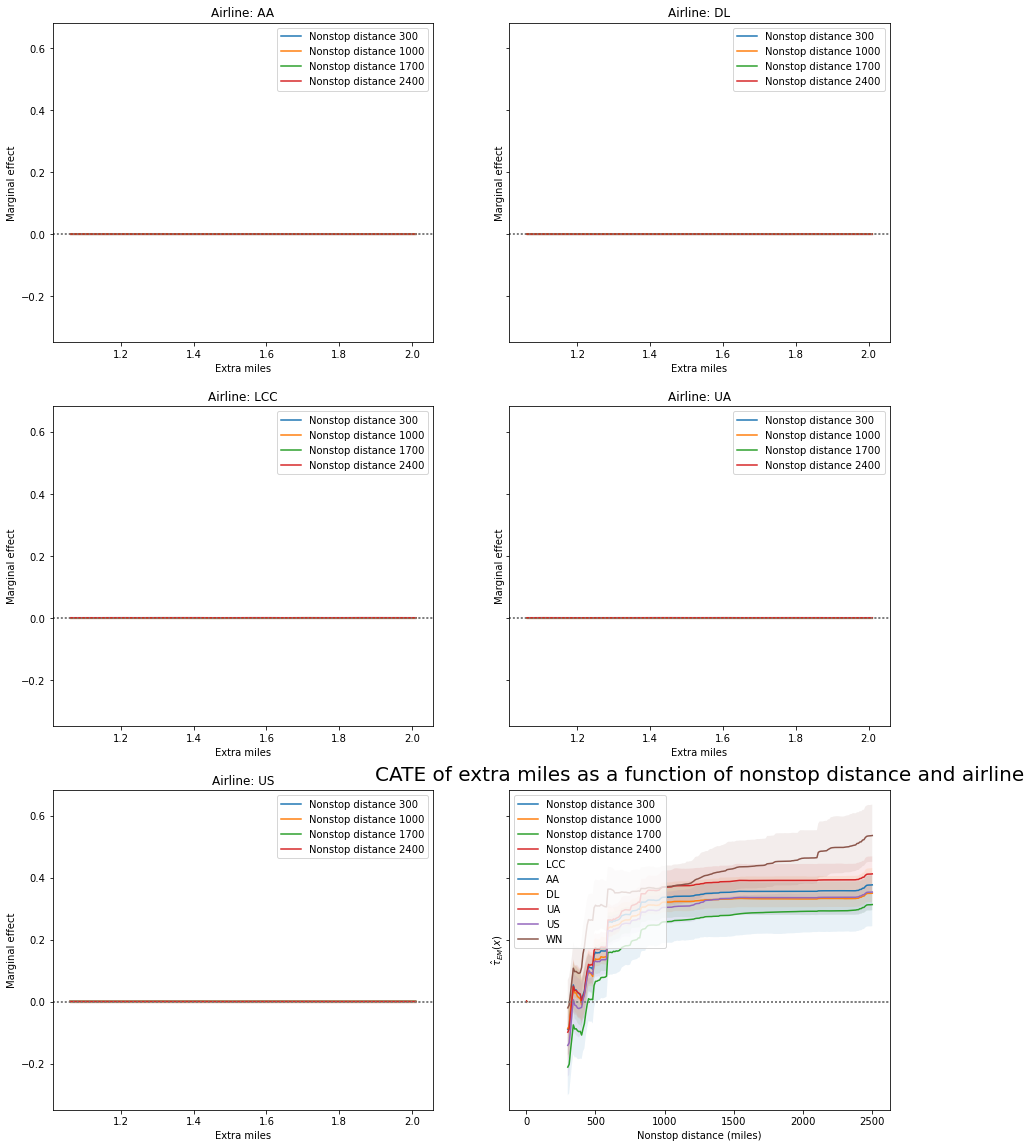


3/3 [==============================] - 0s 8ms/step
(44.7) | Iteration time: 347.5

3/3 [==============================] - 0s 0s/step
(75.4) | Iteration time: 369.6

3/3 [==============================] - 0s 8ms/step
(56.9) | Iteration time: 350.8

3/3 [==============================] - 0s 8ms/step
(44.4) | Iteration time: 341.5

3/3 [==============================] - 0s 8ms/step
(56.2) | Iteration time: 354.7

3/3 [==============================] - 0s 0s/step
(84.0) | Iteration time: 382.3

3/3 [==============================] - 0s 0s/step
(43.2) | Iteration time: 335.8

3/3 [==============================] - 0s 0s/step
(52.7) | Iteration time: 351.0

3/3 [==============================] - 0s 8ms/step
(62.2) | Iteration time: 360.2

3/3 [==============================] - 0s 0s/step
(32.7) | Iteration time: 332.5

3/3 [==============================] - 0s 0s/step
(112.4) | Iteration time: 415.7

3/3 [==============================] - 0s 0s/step
(63.2) | Iteration time: 356.2

3/3 [====

3/3 [==============================] - 0s 8ms/step
(39.4) | Iteration time: 340.2

3/3 [==============================] - 0s 0s/step
(155.8) | Iteration time: 456.5

3/3 [==============================] - 0s 0s/step
(65.1) | Iteration time: 361.4

3/3 [==============================] - 0s 0s/step
(73.2) | Iteration time: 378.5

3/3 [==============================] - 0s 0s/step
(58.5) | Iteration time: 355.9

3/3 [==============================] - 0s 0s/step
(58.0) | Iteration time: 356.7

3/3 [==============================] - 0s 0s/step
(76.5) | Iteration time: 378.9

3/3 [==============================] - 0s 0s/step
(50.8) | Iteration time: 355.4

3/3 [==============================] - 0s 0s/step
(77.4) | Iteration time: 388.2

3/3 [==============================] - 0s 0s/step
(64.2) | Iteration time: 361.9

3/3 [==============================] - 0s 0s/step
(96.2) | Iteration time: 393.9

3/3 [==============================] - 0s 8ms/step
(83.9) | Iteration time: 388.2

3/3 [========

3/3 [==============================] - 0s 0s/step
(57.2) | Iteration time: 358.4

3/3 [==============================] - 0s 0s/step
(77.7) | Iteration time: 381.3

3/3 [==============================] - 0s 8ms/step
(98.2) | Iteration time: 403.4

3/3 [==============================] - 0s 0s/step
(52.3) | Iteration time: 356.3

3/3 [==============================] - 0s 0s/step
(98.3) | Iteration time: 409.2

3/3 [==============================] - 0s 0s/step
(52.7) | Iteration time: 355.6

3/3 [==============================] - 0s 0s/step
(125.7) | Iteration time: 429.6

3/3 [==============================] - 0s 8ms/step
(77.5) | Iteration time: 384.4

3/3 [==============================] - 0s 8ms/step
(65.6) | Iteration time: 375.5

3/3 [==============================] - 0s 3ms/step
(43.4) | Iteration time: 368.9

3/3 [==============================] - 0s 3ms/step
(79.4) | Iteration time: 400.8

3/3 [==============================] - 0s 2ms/step
(74.5) | Iteration time: 381.3

3/3 [====

3/3 [==============================] - 0s 0s/step
(59.4) | Iteration time: 369.9

3/3 [==============================] - 0s 8ms/step
(47.6) | Iteration time: 363.5

3/3 [==============================] - 0s 8ms/step
(62.2) | Iteration time: 376.5

3/3 [==============================] - 0s 0s/step
(48.1) | Iteration time: 356.3

3/3 [==============================] - 0s 8ms/step
(126.4) | Iteration time: 434.9

3/3 [==============================] - 0s 0s/step
(40.8) | Iteration time: 352.4

3/3 [==============================] - 0s 8ms/step
(60.1) | Iteration time: 372.7

3/3 [==============================] - 0s 0s/step
(92.4) | Iteration time: 409.4

3/3 [==============================] - 0s 8ms/step
(40.6) | Iteration time: 354.4

3/3 [==============================] - 0s 8ms/step
(40.7) | Iteration time: 353.2

3/3 [==============================] - 0s 0s/step
(46.2) | Iteration time: 363.5

3/3 [==============================] - 0s 0s/step
(85.4) | Iteration time: 402.9

3/3 [====

3/3 [==============================] - 0s 8ms/step
(41.4) | Iteration time: 356.5

3/3 [==============================] - 0s 8ms/step
(48.6) | Iteration time: 367.2

3/3 [==============================] - 0s 0s/step
(81.7) | Iteration time: 402.6

3/3 [==============================] - 0s 0s/step
(69.8) | Iteration time: 394.6

3/3 [==============================] - 0s 0s/step
(106.0) | Iteration time: 420.7

3/3 [==============================] - 0s 8ms/step
(100.0) | Iteration time: 418.6


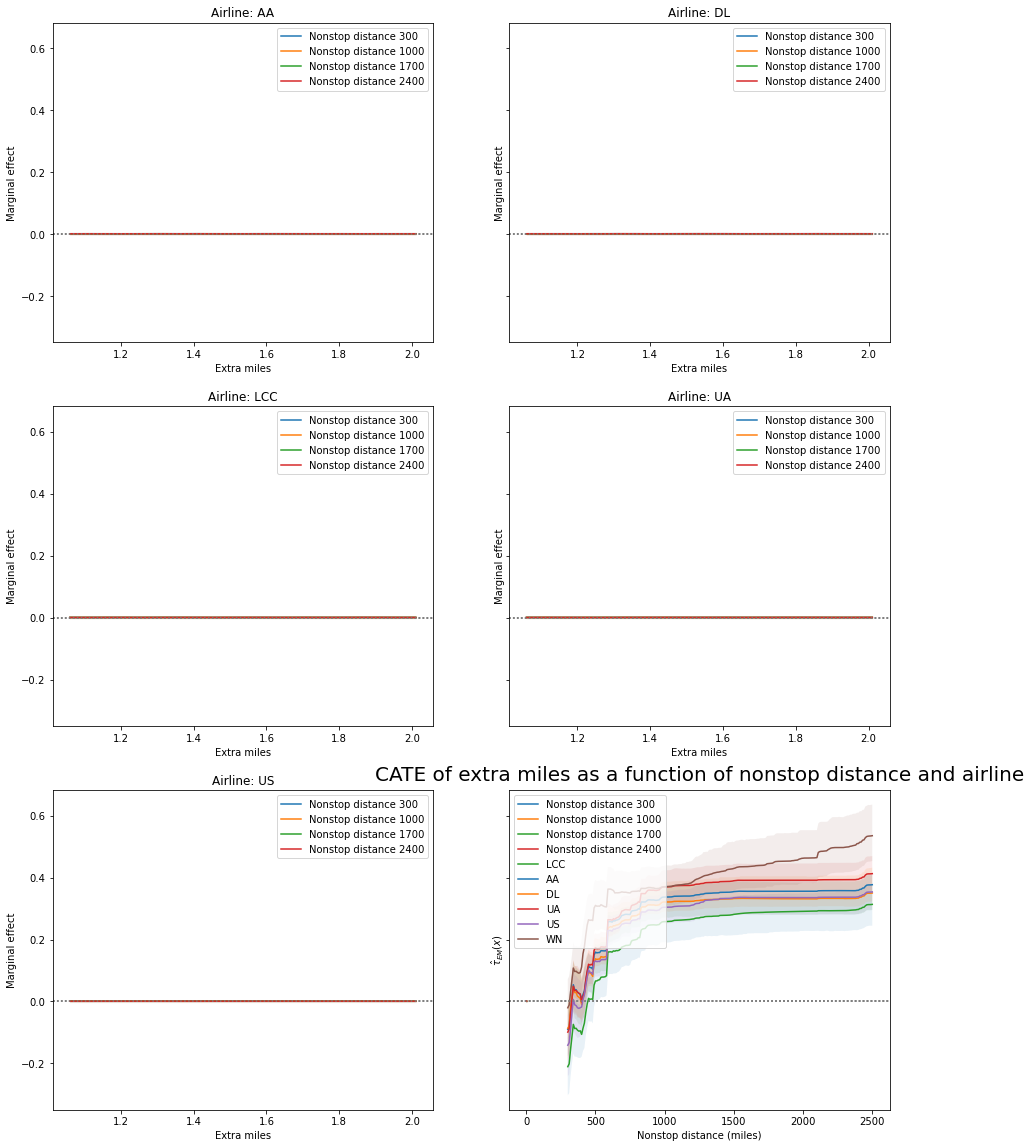


3/3 [==============================] - 0s 8ms/step
(82.9) | Iteration time: 403.8

3/3 [==============================] - 0s 8ms/step
(62.4) | Iteration time: 381.9

3/3 [==============================] - 0s 0s/step
(61.2) | Iteration time: 374.4

3/3 [==============================] - 0s 8ms/step
(105.2) | Iteration time: 425.2

3/3 [==============================] - 0s 0s/step
(105.8) | Iteration time: 420.5

3/3 [==============================] - 0s 8ms/step
(126.1) | Iteration time: 449.4

3/3 [==============================] - 0s 0s/step
(89.6) | Iteration time: 409.1

3/3 [==============================] - 0s 8ms/step
(34.8) | Iteration time: 348.7

3/3 [==============================] - 0s 8ms/step
(131.8) | Iteration time: 451.9

3/3 [==============================] - 0s 0s/step
(54.5) | Iteration time: 380.0

3/3 [==============================] - 0s 0s/step
(46.6) | Iteration time: 368.4

3/3 [==============================] - 0s 0s/step
(94.9) | Iteration time: 417.1

3/3 [

3/3 [==============================] - 0s 0s/step
(77.4) | Iteration time: 404.4

3/3 [==============================] - 0s 8ms/step
(83.6) | Iteration time: 406.1

3/3 [==============================] - 0s 8ms/step
(80.7) | Iteration time: 408.2

3/3 [==============================] - 0s 8ms/step
(78.2) | Iteration time: 407.9

3/3 [==============================] - 0s 0s/step
(96.4) | Iteration time: 416.3

3/3 [==============================] - 0s 8ms/step
(113.4) | Iteration time: 436.0

3/3 [==============================] - 0s 0s/step
(57.2) | Iteration time: 383.8

3/3 [==============================] - 0s 8ms/step
(139.0) | Iteration time: 468.4

3/3 [==============================] - 0s 0s/step
(66.4) | Iteration time: 399.7

3/3 [==============================] - 0s 0s/step
(99.3) | Iteration time: 424.2

3/3 [==============================] - 0s 8ms/step
(117.1) | Iteration time: 444.6

3/3 [==============================] - 0s 0s/step
(91.0) | Iteration time: 418.7

3/3 [==

3/3 [==============================] - 0s 0s/step
(37.8) | Iteration time: 367.5

3/3 [==============================] - 0s 8ms/step
(51.6) | Iteration time: 377.7

3/3 [==============================] - 0s 0s/step
(73.3) | Iteration time: 399.0

3/3 [==============================] - 0s 0s/step
(58.0) | Iteration time: 388.5

3/3 [==============================] - 0s 0s/step
(90.5) | Iteration time: 424.0

3/3 [==============================] - 0s 8ms/step
(81.5) | Iteration time: 418.6

3/3 [==============================] - 0s 0s/step
(57.5) | Iteration time: 387.4

3/3 [==============================] - 0s 0s/step
(107.1) | Iteration time: 431.9

3/3 [==============================] - 0s 8ms/step
(43.1) | Iteration time: 369.9

3/3 [==============================] - 0s 8ms/step
(89.8) | Iteration time: 424.4

3/3 [==============================] - 0s 0s/step
(87.6) | Iteration time: 426.1

3/3 [==============================] - 0s 0s/step
(99.8) | Iteration time: 426.5

3/3 [======

3/3 [==============================] - 0s 8ms/step
(64.0) | Iteration time: 399.6

3/3 [==============================] - 0s 8ms/step
(85.4) | Iteration time: 427.0

3/3 [==============================] - 0s 0s/step
(133.8) | Iteration time: 476.4

3/3 [==============================] - 0s 0s/step
(38.3) | Iteration time: 381.6

3/3 [==============================] - 0s 0s/step
(72.8) | Iteration time: 402.1

3/3 [==============================] - 0s 0s/step
(129.9) | Iteration time: 460.5

3/3 [==============================] - 0s 8ms/step
(102.9) | Iteration time: 434.9

3/3 [==============================] - 0s 8ms/step
(45.1) | Iteration time: 378.9

3/3 [==============================] - 0s 8ms/step
(116.8) | Iteration time: 461.4

3/3 [==============================] - 0s 8ms/step
(110.2) | Iteration time: 445.8

3/3 [==============================] - 0s 0s/step
(110.7) | Iteration time: 442.6

3/3 [==============================] - 0s 8ms/step
(58.5) | Iteration time: 395.1

3/3

3/3 [==============================] - 0s 0s/step
(103.0) | Iteration time: 444.5

3/3 [==============================] - 0s 0s/step
(67.8) | Iteration time: 413.0

3/3 [==============================] - 0s 0s/step
(87.1) | Iteration time: 424.3

3/3 [==============================] - 0s 0s/step
(66.9) | Iteration time: 402.0

3/3 [==============================] - 0s 0s/step
(114.8) | Iteration time: 460.2

3/3 [==============================] - 0s 0s/step
(74.5) | Iteration time: 416.5


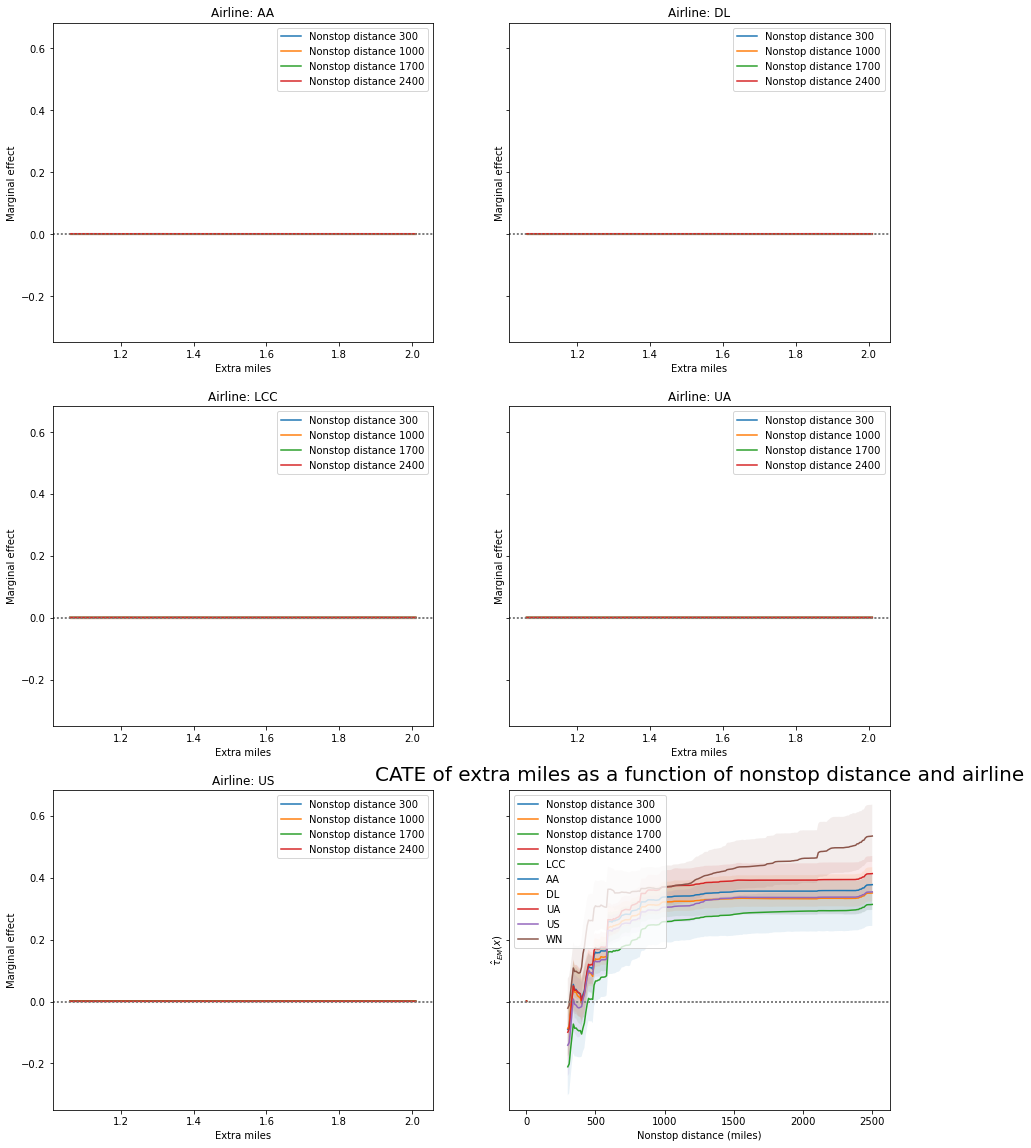


3/3 [==============================] - 0s 8ms/step
(39.3) | Iteration time: 391.0

3/3 [==============================] - 0s 0s/step
(132.1) | Iteration time: 472.7

3/3 [==============================] - 0s 8ms/step
(65.7) | Iteration time: 403.0

3/3 [==============================] - 0s 8ms/step
(60.3) | Iteration time: 407.4

3/3 [==============================] - 0s 8ms/step
(53.9) | Iteration time: 401.9

3/3 [==============================] - 0s 0s/step
(67.0) | Iteration time: 429.9

3/3 [==============================] - 0s 0s/step
(66.4) | Iteration time: 434.5

3/3 [==============================] - 0s 0s/step
(83.2) | Iteration time: 442.6

3/3 [==============================] - 0s 0s/step
(95.7) | Iteration time: 438.5

3/3 [==============================] - 0s 8ms/step
(52.8) | Iteration time: 398.8

3/3 [==============================] - 0s 0s/step
(62.6) | Iteration time: 404.2

3/3 [==============================] - 0s 0s/step
(89.3) | Iteration time: 430.3

3/3 [====

3/3 [==============================] - 0s 8ms/step
(94.1) | Iteration time: 443.5

3/3 [==============================] - 0s 8ms/step
(38.0) | Iteration time: 384.6

3/3 [==============================] - 0s 8ms/step
(132.5) | Iteration time: 485.0

3/3 [==============================] - 0s 0s/step
(98.4) | Iteration time: 443.2

3/3 [==============================] - 0s 0s/step
(97.8) | Iteration time: 441.5

3/3 [==============================] - 0s 8ms/step
(115.5) | Iteration time: 469.7

3/3 [==============================] - 0s 0s/step
(81.1) | Iteration time: 433.6

3/3 [==============================] - 0s 8ms/step
(100.1) | Iteration time: 458.2

3/3 [==============================] - 0s 8ms/step
(39.6) | Iteration time: 391.7

3/3 [==============================] - 0s 8ms/step
(90.2) | Iteration time: 435.5

3/3 [==============================] - 0s 0s/step
(119.3) | Iteration time: 476.9

3/3 [==============================] - 0s 0s/step
(60.5) | Iteration time: 411.3

3/3 [

3/3 [==============================] - 0s 8ms/step
(62.5) | Iteration time: 422.5

3/3 [==============================] - 0s 0s/step
(68.2) | Iteration time: 417.0

3/3 [==============================] - 0s 0s/step
(39.4) | Iteration time: 388.4

3/3 [==============================] - 0s 0s/step
(70.0) | Iteration time: 420.1

3/3 [==============================] - 0s 0s/step
(84.3) | Iteration time: 444.3

3/3 [==============================] - 0s 0s/step
(123.4) | Iteration time: 487.3

3/3 [==============================] - 0s 0s/step
(91.8) | Iteration time: 449.7

3/3 [==============================] - 0s 8ms/step
(127.0) | Iteration time: 481.2

3/3 [==============================] - 0s 0s/step
(82.8) | Iteration time: 441.7

3/3 [==============================] - 0s 0s/step
(86.7) | Iteration time: 450.6

3/3 [==============================] - 0s 0s/step
(78.5) | Iteration time: 438.5

3/3 [==============================] - 0s 8ms/step


3/3 [==============================] - 0s 8ms/step
(65.1) | Iteration time: 425.0

3/3 [==============================] - 0s 8ms/step
(107.4) | Iteration time: 460.4

3/3 [==============================] - 0s 8ms/step
(69.7) | Iteration time: 421.6

3/3 [==============================] - 0s 0s/step
(101.6) | Iteration time: 459.3

3/3 [==============================] - 0s 0s/step
(84.0) | Iteration time: 447.1

3/3 [==============================] - 0s 0s/step
(142.4) | Iteration time: 503.5

3/3 [==============================] - 0s 8ms/step
(86.2) | Iteration time: 439.6

3/3 [==============================] - 0s 0s/step
(118.8) | Iteration time: 471.5

3/3 [==============================] - 0s 0s/step
(86.1) | Iteration time: 439.4

3/3 [==============================] - 0s 0s/step
(92.7) | Iteration time: 450.2

3/3 [==============================] - 0s 8ms/step
(79.9) | Iteration time: 442.0

3/3 [==============================] - 0s 8ms/step
(123.3) | Iteration time: 477.0

3/3 [

3/3 [==============================] - 0s 0s/step
(93.8) | Iteration time: 453.8

3/3 [==============================] - 0s 8ms/step
(69.1) | Iteration time: 438.1

3/3 [==============================] - 0s 0s/step
(132.5) | Iteration time: 498.5

3/3 [==============================] - 0s 0s/step
(65.4) | Iteration time: 427.2

3/3 [==============================] - 0s 0s/step
(114.1) | Iteration time: 472.5

3/3 [==============================] - 0s 0s/step
(73.6) | Iteration time: 434.6

3/3 [==============================] - 0s 0s/step
(119.5) | Iteration time: 491.9

3/3 [==============================] - 0s 0s/step
(64.0) | Iteration time: 429.4

3/3 [==============================] - 0s 0s/step
(73.8) | Iteration time: 432.9

3/3 [==============================] - 0s 0s/step
(71.7) | Iteration time: 430.0

3/3 [==============================] - 0s 8ms/step
(192.8) | Iteration time: 556.9

3/3 [==============================] - 0s 8ms/step
(78.8) | Iteration time: 432.5

3/3 [====

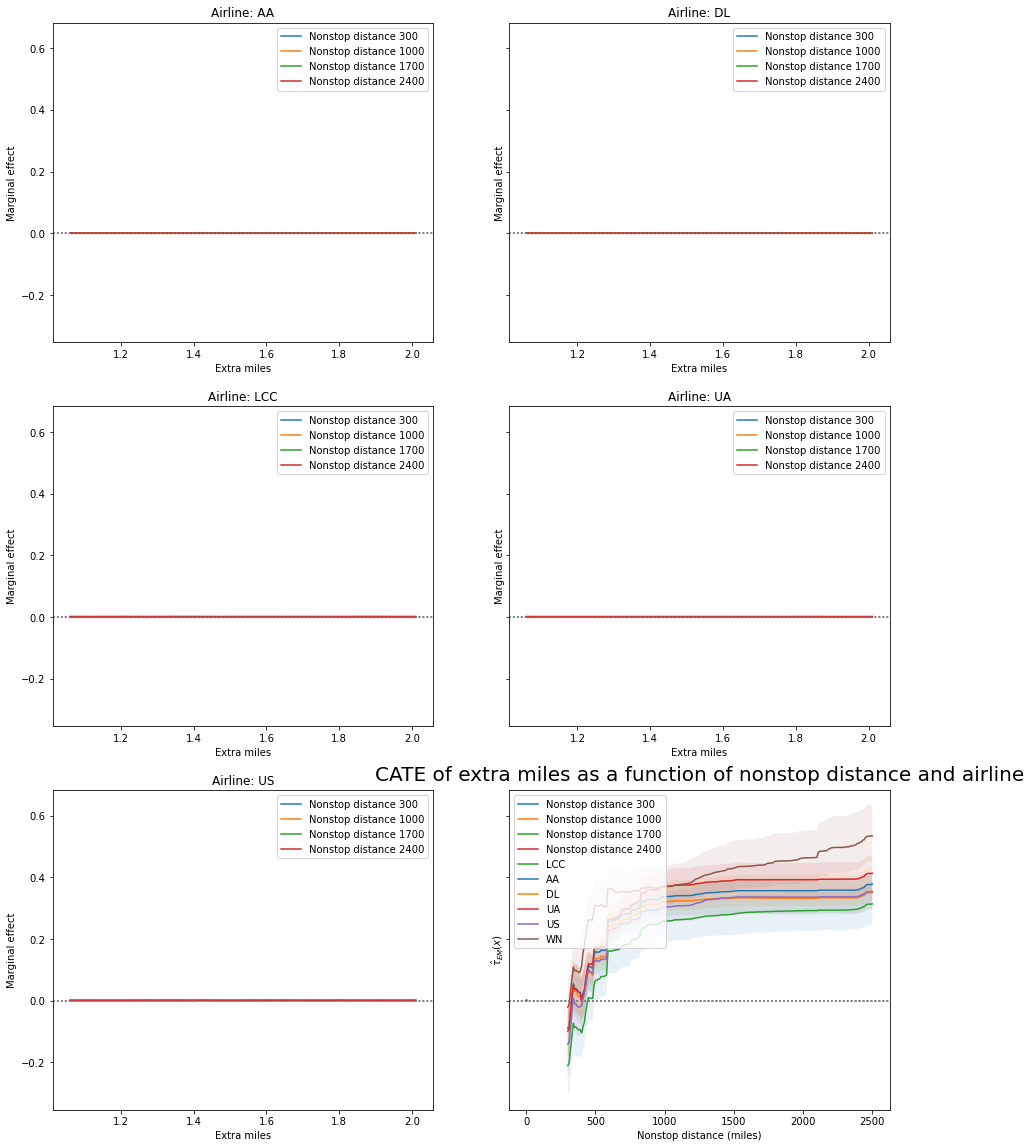


 801 DML1 

KeyboardInterrupt: 

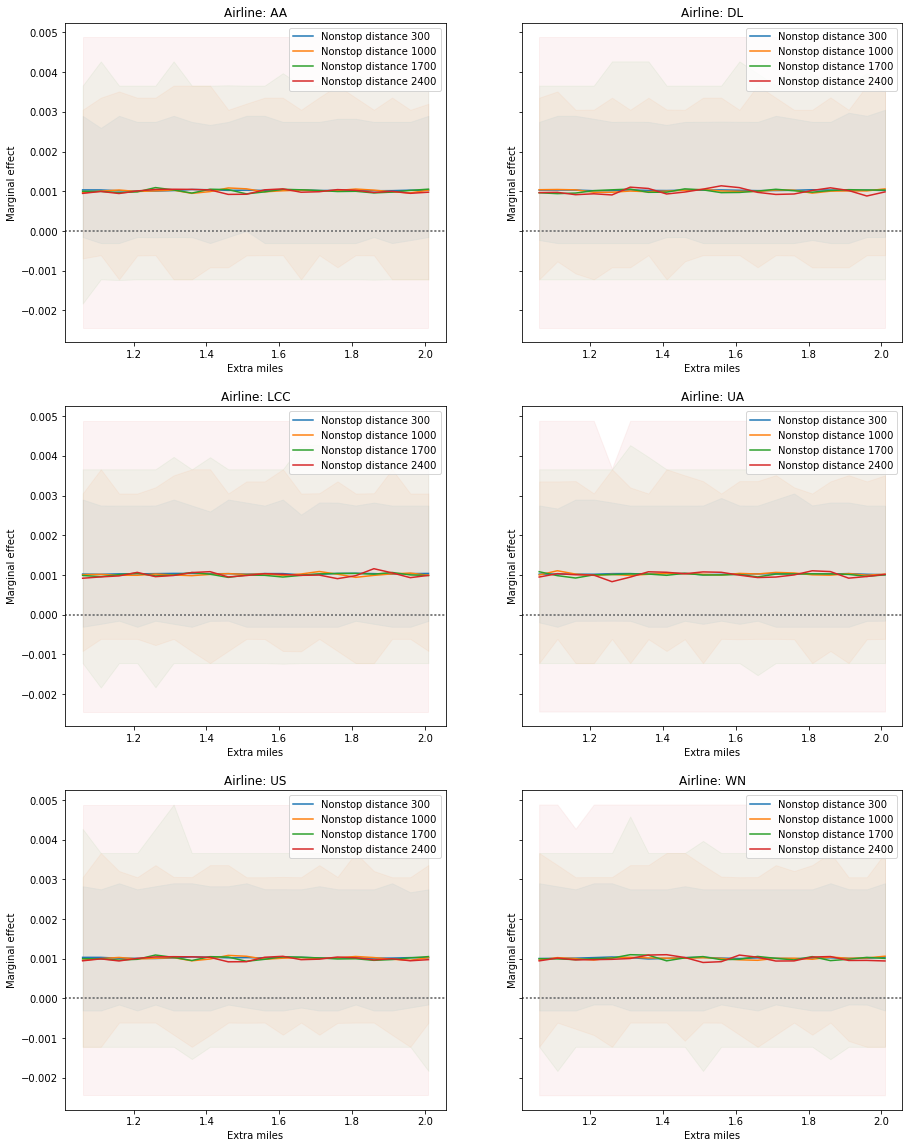

In [6]:
for i in range(1000):
    print('\n', i + 1, end = ' ')
    iter_start = time.time()
    
    # 2/3 of the sample per bootstrap iteration, drawn with replacement
    ind[i] = np.random.choice(list(np.arange(nrow)), nrow)
    
    # First step DML ------------------------------------------------------------------------------------------
    print('DML1', end = ' ')
    start = time.time()
    dmliv_est = DMLIV(model_y_xw  = xgb.XGBRegressor(max_depth = 6, n_estimators = 450, learning_rate = 0.1),
                      model_t_xw  = xgb.XGBRegressor(max_depth = 5, n_estimators = 1000, learning_rate = 0.1),
                      model_t_xwz = xgb.XGBRegressor(max_depth = 7, n_estimators = 700, learning_rate = 0.1))
    dmliv_est.fit(Y = y[ind[i][0:int(nrow*2/3)]],
                  T = T[ind[i][0:int(nrow*2/3)],:],
                  Z = Z[ind[i][0:int(nrow*2/3)],:],
                  X = None,
                  W = X[ind[i][0:int(nrow*2/3)],:])
    dml1_l.append(dmliv_est.const_marginal_effect().reshape(-1))
    #pickle.dump(dmliv_est, open(export_dir + f'\\Models\dmliv{i}.sav', 'wb'))
    print(f'({np.round(time.time() - start, 1)})', end = ' ')
    
    # Second step DML ------------------------------------------------------------------------------------------
    print('DML2', end = ' ')
    start = time.time()
    dml_est = LinearDML(model_y = xgb.XGBRegressor(max_depth = 7, n_estimators = 1000, learning_rate = 0.1),
                        model_t = xgb.XGBRegressor(max_depth = 6, n_estimators = 700, learning_rate = 0.1))
    dml_est.fit(Y = y[ind[i][0:int(nrow*2/3)]] - T[ind[i][0:int(nrow*2/3)],:] @ dml1_l[i],
                T = X[ind[i][0:int(nrow*2/3)],3],
                X = None,
                W = np.delete(X[ind[i][0:int(nrow*2/3)],:], 3, 1))
    dml2_l.append(dml_est.ate())
    #pickle.dump(dml_est, open(export_dir + f'\\Models\dml2{i}.sav', 'wb'))
    print(f'({np.round(time.time() - start, 1)})', end = ' ')
    
    # GRF ------------------------------------------------------------------------------------------------------
    print('GRF', end = ' ')
    start = time.time()
    grf_NL = CausalForest(criterion='het',
                          n_estimators=1000,
                          min_samples_leaf=50,
                          max_depth=8,
                          min_impurity_decrease = 0.0,
                          max_samples=0.45,
                          max_features='sqrt',
                          warm_start=False,
                          inference=False,
                          fit_intercept=True,
                          subforest_size=4,
                          honest=True,
                          verbose=0,
                          n_jobs=-1)
    grf_NL.fit(X = np.delete(X[ind[i][0:int(nrow*2/3)],:], 3, 1),
               y = y[ind[i][0:int(nrow*2/3)]] - T[ind[i][0:int(nrow*2/3)],:] @ dml1_l[i],
               T = X[ind[i][0:int(nrow*2/3)],3].reshape(-1,1))
    grf_l.append(grf_NL.predict(np.delete(X, 3, 1)))
    AA_ests_grf.append(grf_NL.predict(AA_grid_grf))
    DL_ests_grf.append(grf_NL.predict(DL_grid_grf))
    LCC_ests_grf.append(grf_NL.predict(LCC_grid_grf))
    UA_ests_grf.append(grf_NL.predict(UA_grid_grf))
    US_ests_grf.append(grf_NL.predict(US_grid_grf))
    WN_ests_grf.append(grf_NL.predict(WN_grid_grf))
    #pickle.dump(grf_NL, open(export_dir + f'\\Models\grf{i}.sav', 'wb'))
    print(f'({np.round(time.time() - start, 1)})', end = ' ')
    
    # MLP ------------------------------------------------------------------------------------------------------
    print('MLP', end = ' ')
    start = time.time()
    norm_layer = keras.layers.Normalization()
    norm_layer.adapt(X[ind[i][0:int(nrow*2/3)],:])
    mlp = keras.Sequential()
    mlp.add(norm_layer)
    mlp.add(keras.layers.Dense(128, activation = 'relu'))
    mlp.add(keras.layers.Dense(64, activation = 'relu'))
    mlp.add(keras.layers.Dense(1))
    mlp.compile(optimizer = 'adam', loss = 'mean_squared_error')
    mlp.fit(X[ind[i][0:int(nrow*2/3)],:],
            y[ind[i][0:int(nrow*2/3)]] - T[ind[i][0:int(nrow*2/3)],:] @ dml1_l[i],
            epochs = 50,
            validation_split = 0.1,
            verbose = False,
            callbacks = keras.callbacks.EarlyStopping(patience = 2, restore_best_weights = True))
    mlp_l.append(mlp.predict(X))
    AA_ests_mlp.append((mlp.predict(AA_grid2_mlp) - mlp.predict(AA_grid1_mlp)) * 10)
    DL_ests_mlp.append((mlp.predict(DL_grid2_mlp) - mlp.predict(DL_grid1_mlp)) * 10)
    LCC_ests_mlp.append((mlp.predict(LCC_grid2_mlp) - mlp.predict(LCC_grid1_mlp)) * 10)
    UA_ests_mlp.append((mlp.predict(UA_grid2_mlp) - mlp.predict(UA_grid1_mlp)) * 10)
    US_ests_mlp.append((mlp.predict(US_grid2_mlp) - mlp.predict(US_grid1_mlp)) * 10)
    WN_ests_mlp.append((mlp.predict(WN_grid2_mlp) - mlp.predict(WN_grid1_mlp)) * 10)
    #mlp.save(export_dir + f'\\Models\mlp{i}.h5')
    print(f'({np.round(time.time() - start, 1)})', end = ' ')
    
    print(f'| Iteration time: {np.round(time.time() - iter_start, 1)}')
    
    # ----------------------------------------------------------------------------------------------------------
    # ----------------------------------------------------------------------------------------------------------
    
    # Adding a checkpoint after each 100 iterations:
    if (i+1)%100 == 0:
        # Exporting estimates
        try:
            os.mkdir(export_dir + '\\Estimates')
        except:
            None
        pd.DataFrame(
            {
                'alpha': np.array(dml1_l)[:,0],
                'rho': np.array(dml1_l)[:,1]
            }
        ).to_csv(export_dir + '\\Estimates\dml1.csv', index = False)
        pd.DataFrame(np.array(dml2_l)).to_csv(export_dir + '\\Estimates\dml2.csv', index = False)
        pd.DataFrame(np.array(grf_l).reshape(-1, 100)).to_csv(export_dir + '\\Estimates\grf.csv', index = False)
        pd.DataFrame(np.array(mlp_l).reshape(-1, 100)).to_csv(export_dir + '\\Estimates\mlp.csv', index = False)
        pd.DataFrame(ind).to_csv(export_dir + '\\Estimates\index.csv', index = False)
        
        # Exporting mean GRF estimates together with covariates
        grf_estimates = np.mean(np.array(grf_l).reshape(i+1,-1), axis = 0)
        covariates_scaled = pd.DataFrame(preprocessing.scale(np.delete(X[X[:,0] == 0, :], [0,3], 1)),
                                         columns = ['presence_origin', 'presence_dest', 'nonstop_miles', 'popestimate1', 'popestimate2',
                                                    'DL', 'LCC', 'UA', 'US', 'WN'])
        covariates_scaled['grf_ests'] = grf_estimates[X[:,0] == 0]
        covariates_scaled.to_csv('Second step correlations set.csv', index = False)
        
        # Plotting the GRF CATEs -------------------------------------------------------------------------------
        plt.plot(np.arange(300, 2501, 10),
                 np.mean(LCC_ests_grf, axis = 0), c = 'C2', label = 'LCC')
        plt.fill_between(np.arange(300, 2501, 10),
                         np.percentile(LCC_ests_grf, 2.5, axis = 0).reshape(-1),
                         np.percentile(LCC_ests_grf, 97.5, axis = 0).reshape(-1),
                         alpha = 0.1)
        plt.plot(np.arange(300, 2501, 10),
                 np.mean(AA_ests_grf, axis = 0), c = 'C0', label = 'AA')
        plt.fill_between(np.arange(300, 2501, 10),
                         np.percentile(AA_ests_grf, 2.5, axis = 0).reshape(-1),
                         np.percentile(AA_ests_grf, 97.5, axis = 0).reshape(-1),
                         alpha = 0.1)
        plt.plot(np.arange(300, 2501, 10),
                 np.mean(DL_ests_grf, axis = 0), c = 'C1', label = 'DL')
        plt.fill_between(np.arange(300, 2501, 10),
                         np.percentile(DL_ests_grf, 2.5, axis = 0).reshape(-1),
                         np.percentile(DL_ests_grf, 97.5, axis = 0).reshape(-1),
                         alpha = 0.1)
        plt.plot(np.arange(300, 2501, 10),
                 np.mean(UA_ests_grf, axis = 0), c = 'C3', label = 'UA')
        plt.fill_between(np.arange(300, 2501, 10),
                         np.percentile(UA_ests_grf, 2.5, axis = 0).reshape(-1),
                         np.percentile(UA_ests_grf, 97.5, axis = 0).reshape(-1),
                         alpha = 0.1)
        plt.plot(np.arange(300, 2501, 10),
                 np.mean(US_ests_grf, axis = 0), c = 'C4', label = 'US')
        plt.fill_between(np.arange(300, 2501, 10),
                         np.percentile(US_ests_grf, 2.5, axis = 0).reshape(-1),
                         np.percentile(US_ests_grf, 97.5, axis = 0).reshape(-1),
                         alpha = 0.1)
        plt.plot(np.arange(300, 2501, 10),
                 np.mean(WN_ests_grf, axis = 0), c = 'C5', label = 'WN')
        plt.fill_between(np.arange(300, 2501, 10),
                         np.percentile(WN_ests_grf, 2.5, axis = 0).reshape(-1),
                         np.percentile(WN_ests_grf, 97.5, axis = 0).reshape(-1),
                         alpha = 0.1)
        plt.axhline(0, color = 'grey', ls = 'dotted')
        plt.xlabel('Nonstop distance (miles)')
        plt.ylabel('$\hat{\\tau}_{EM}(x)$')
        plt.title('CATE of extra miles as a function of nonstop distance and airline', fontsize = 20, pad = 10)
        plt.legend(loc = 'upper left')
        plt.show()
        
        # Plotting the NN marginal effects ---------------------------------------------------------------------
        indices = [(i,j) for i in range(3) for j in range(2)]
        fig, ax = plt.subplots(nrows = 3, ncols = 2, figsize = (15, 20), sharey = True)
        for c,i in enumerate(np.arange(300,2401,700)):
            ax[indices[0]].plot(np.arange(1.01,2,0.05) + 0.05,
                     np.mean(US_ests_mlp, axis = 0)[AA_grid1_mlp[:,3] == i].reshape(-1), c = f'C{c}', label = f'Nonstop distance {i}')
            ax[indices[0]].fill_between(np.arange(1.01,2,0.05) + 0.05,
                             np.percentile(AA_ests_mlp, 2.5, axis = 0)[AA_grid1_mlp[:,3] == i].reshape(-1),
                             np.percentile(AA_ests_mlp, 97.5, axis = 0)[AA_grid1_mlp[:,3] == i].reshape(-1),
                             alpha = 0.05, color = f'C{c}')
            ax[indices[0]].axhline(0, color = 'grey', ls = 'dotted')
            ax[indices[0]].legend()
            ax[indices[0]].set_title('Airline: AA')
            ax[indices[0]].set(xlabel = 'Extra miles', ylabel = 'Marginal effect')
            ax[indices[1]].plot(np.arange(1.01,2,0.05) + 0.05,
                     np.mean(DL_ests_mlp, axis = 0)[DL_grid1_mlp[:,3] == i].reshape(-1), c = f'C{c}', label = f'Nonstop distance {i}')
            ax[indices[1]].fill_between(np.arange(1.01,2,0.05) + 0.05,
                             np.percentile(DL_ests_mlp, 2.5, axis = 0)[DL_grid1_mlp[:,3] == i].reshape(-1),
                             np.percentile(DL_ests_mlp, 97.5, axis = 0)[DL_grid1_mlp[:,3] == i].reshape(-1),
                             alpha = 0.05, color = f'C{c}')
            ax[indices[1]].axhline(0, color = 'grey', ls = 'dotted')
            ax[indices[1]].legend()
            ax[indices[1]].set_title('Airline: DL')
            ax[indices[1]].set(xlabel = 'Extra miles', ylabel = 'Marginal effect')
            ax[indices[2]].plot(np.arange(1.01,2,0.05) + 0.05,
                     np.mean(LCC_ests_mlp, axis = 0)[LCC_grid1_mlp[:,3] == i].reshape(-1), c = f'C{c}', label = f'Nonstop distance {i}')
            ax[indices[2]].fill_between(np.arange(1.01,2,0.05) + 0.05,
                             np.percentile(LCC_ests_mlp, 2.5, axis = 0)[LCC_grid1_mlp[:,3] == i].reshape(-1),
                             np.percentile(LCC_ests_mlp, 97.5, axis = 0)[LCC_grid1_mlp[:,3] == i].reshape(-1),
                             alpha = 0.05, color = f'C{c}')
            ax[indices[2]].axhline(0, color = 'grey', ls = 'dotted')
            ax[indices[2]].legend()
            ax[indices[2]].set_title('Airline: LCC')
            ax[indices[2]].set(xlabel = 'Extra miles', ylabel = 'Marginal effect')
            ax[indices[3]].plot(np.arange(1.01,2,0.05) + 0.05,
                     np.mean(UA_ests_mlp, axis = 0)[UA_grid1_mlp[:,3] == i].reshape(-1), c = f'C{c}', label = f'Nonstop distance {i}')
            ax[indices[3]].fill_between(np.arange(1.01,2,0.05) + 0.05,
                             np.percentile(UA_ests_mlp, 2.5, axis = 0)[UA_grid1_mlp[:,3] == i].reshape(-1),
                             np.percentile(UA_ests_mlp, 97.5, axis = 0)[UA_grid1_mlp[:,3] == i].reshape(-1),
                             alpha = 0.05, color = f'C{c}')
            ax[indices[3]].axhline(0, color = 'grey', ls = 'dotted')
            ax[indices[3]].legend()
            ax[indices[3]].set_title('Airline: UA')
            ax[indices[3]].set(xlabel = 'Extra miles', ylabel = 'Marginal effect')
            ax[indices[4]].plot(np.arange(1.01,2,0.05) + 0.05,
                     np.mean(US_ests_mlp, axis = 0)[US_grid1_mlp[:,3] == i].reshape(-1), c = f'C{c}', label = f'Nonstop distance {i}')
            ax[indices[4]].fill_between(np.arange(1.01,2,0.05) + 0.05,
                             np.percentile(US_ests_mlp, 2.5, axis = 0)[US_grid1_mlp[:,3] == i].reshape(-1),
                             np.percentile(US_ests_mlp, 97.5, axis = 0)[US_grid1_mlp[:,3] == i].reshape(-1),
                             alpha = 0.05, color = f'C{c}')
            ax[indices[4]].axhline(0, color = 'grey', ls = 'dotted')
            ax[indices[4]].legend()
            ax[indices[4]].set_title('Airline: US')
            ax[indices[4]].set(xlabel = 'Extra miles', ylabel = 'Marginal effect')
            ax[indices[5]].plot(np.arange(1.01,2,0.05) + 0.05,
                     np.mean(WN_ests_mlp, axis = 0)[WN_grid1_mlp[:,3] == i].reshape(-1), c = f'C{c}', label = f'Nonstop distance {i}')
            ax[indices[5]].fill_between(np.arange(1.01,2,0.05) + 0.05,
                             np.percentile(WN_ests_mlp, 2.5, axis = 0)[WN_grid1_mlp[:,3] == i].reshape(-1),
                             np.percentile(WN_ests_mlp, 97.5, axis = 0)[WN_grid1_mlp[:,3] == i].reshape(-1),
                             alpha = 0.05, color = f'C{c}')
            ax[indices[5]].axhline(0, color = 'grey', ls = 'dotted')
            ax[indices[5]].legend()
            ax[indices[5]].set_title('Airline: WN')
            ax[indices[5]].set(xlabel = 'Extra miles', ylabel = 'Marginal effect')

Storing the full results:

In [8]:
try:
    os.mkdir(export_dir + '\\Estimates')
except:
    None


pd.DataFrame(
    {
        'alpha': np.array(dml1_l)[:,0],
        'rho': np.array(dml1_l)[:,1]
    }
).to_csv(export_dir + '\\Estimates\dml1.csv', index = False)
pd.DataFrame(np.array(dml2_l)).to_csv(export_dir + '\\Estimates\dml2.csv', index = False)
pd.DataFrame(np.array(grf_l).reshape(-1, 100)).to_csv(export_dir + '\\Estimates\grf.csv', index = False)
pd.DataFrame(np.array(mlp_l).reshape(-1, 100)).to_csv(export_dir + '\\Estimates\mlp.csv', index = False)
pd.DataFrame(ind).to_csv(export_dir + '\\Estimates\index.csv', index = False)

# 3. Analysis

### First step DML

* Means of bootstrap coefficient estimates
* Standard deviations of coefficient estimates in parentheses
* 2.5th and 97.5th percentiles of coefficient estimates in square brackets

In [25]:
alpha, rho = np.mean(np.array(dml1_l), axis = 0)
alpha_se, rho_se = np.std(np.array(dml1_l), axis = 0)

print(f'Alpha: {round(alpha * 100, 4)} ({round(alpha_se * 100, 4)}) [{round(np.percentile(np.array(dml1_l)[:,0] * 100, 2.5), 4)}, {round(np.percentile(np.array(dml1_l)[:,0] * 100, 97.5), 4)}]') # *100 to get value in terms of 100 dollars
print(f'Rho: {round(rho, 4)} ({round(rho_se, 4)}) [{round(np.percentile(np.array(dml1_l)[:,1], 2.5), 4)}, {round(np.percentile(np.array(dml1_l)[:,1], 97.5), 4)}]')

Alpha: -0.1762 (0.0107) [-0.1977, -0.155]
Rho: 0.8597 (0.0073) [0.8468, 0.8745]


### Elasticities

In [43]:
products['h'] = np.exp((np.log(products.sj) - np.log(products.s0) - rho * np.log(products.sjg)) / (1 - rho))
products['Dg'] = products.groupby(['market_id']).h.transform('sum')
products['own_elasticity'] = (alpha * products.price / (1 - rho)) * (1 - products.sj * (rho * products.Dg ** (rho - 1) + 1))
products['cross_elasticity'] = -(alpha * products.price / (1 - rho)) * products.sj * (rho * products.Dg ** (rho - 1) + 1)

print('Mean own elasticity:', round(products.own_elasticity.mean(), 4))
print('Mean cross elasticity (within nest):', round(products.cross_elasticity.mean(), 4))

Mean own elasticity: -3.324
Mean cross elasticity (within nest): 0.1271


### Second step DML ATE

In [44]:
print(f'Extra miles: {round(np.mean(dml2_l), 4)} ({round(np.std(dml2_l), 4)}) [{round(np.percentile(dml2_l, 2.5), 4)}, {round(np.percentile(dml2_l, 97.5), 4)}]')

Extra miles: 0.0026 (0.0132) [-0.0231, 0.0278]


### Second step GRF CATEs

In [35]:
grf_estimates = np.mean(np.array(grf_l).reshape(-1, nrow), axis = 0)
covariates_scaled = pd.DataFrame(preprocessing.scale(np.delete(X[X[:,0] == 0, :], [0,3], 1)),
                                 columns = ['presence_origin', 'presence_dest', 'nonstop_miles', 'popestimate1', 'popestimate2',
                                            'DL', 'LCC', 'UA', 'US', 'WN'])
covariates_scaled['grf_ests'] = grf_estimates[X[:,0] == 0]
covariates_scaled.to_csv('Second step correlations set.csv', index = False)

In [36]:
sm.OLS(covariates_scaled['grf_ests'], covariates_scaled.drop('grf_ests', axis = 1).assign(intercept = 1)).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               grf_ests   R-squared:                       0.624
Model:                            OLS   Adj. R-squared:                  0.624
Method:                 Least Squares   F-statistic:                 2.747e+04
Date:                Thu, 29 Dec 2022   Prob (F-statistic):               0.00
Time:                        15:41:12   Log-Likelihood:             1.0577e+05
No. Observations:              165666   AIC:                        -2.115e+05
Df Residuals:                  165655   BIC:                        -2.114e+05
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
presence_origin    -0.0168      0.001    -26.929      0.000      -0.018      -0.016
presence_dest      -0.0182      0.001    -29.485      0.000      -0.019      -0.017
nonstop_miles       0.0786      0.000    244.222      0.000       0.078       0.079
popestimate1        0.0684      0.000    216.392      0.000       0.068       0.069
popestimate2        0.0935      0.000    295.850      0.000       0.093       0.094
DL                 -0.0256      0.001    -33.464      0.000      -0.027      -0.024
LCC                -0.1055      0.001   -165.384      0.000      -0.107      -0.104
UA                 -0.0179      0.001    -23.672      0.000      -0.019      -0.016
US                 -0.0258      0.001    -44.898      0.000      -0.027      -0.025
WN                 -0.0069      0.000    -14.094      0.000      -0.008      -0.006
intercept           0.3296      0.000   1049.783      0.000       0.329       0.330
==============================================================================
Omnibus:                    13655.927   Durbin-Watson:                   1.683
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            51271.195
Skew:                          -0.363   Prob(JB):                         0.00
Kurtosis:                       5.627   Cond. No.                         6.55
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

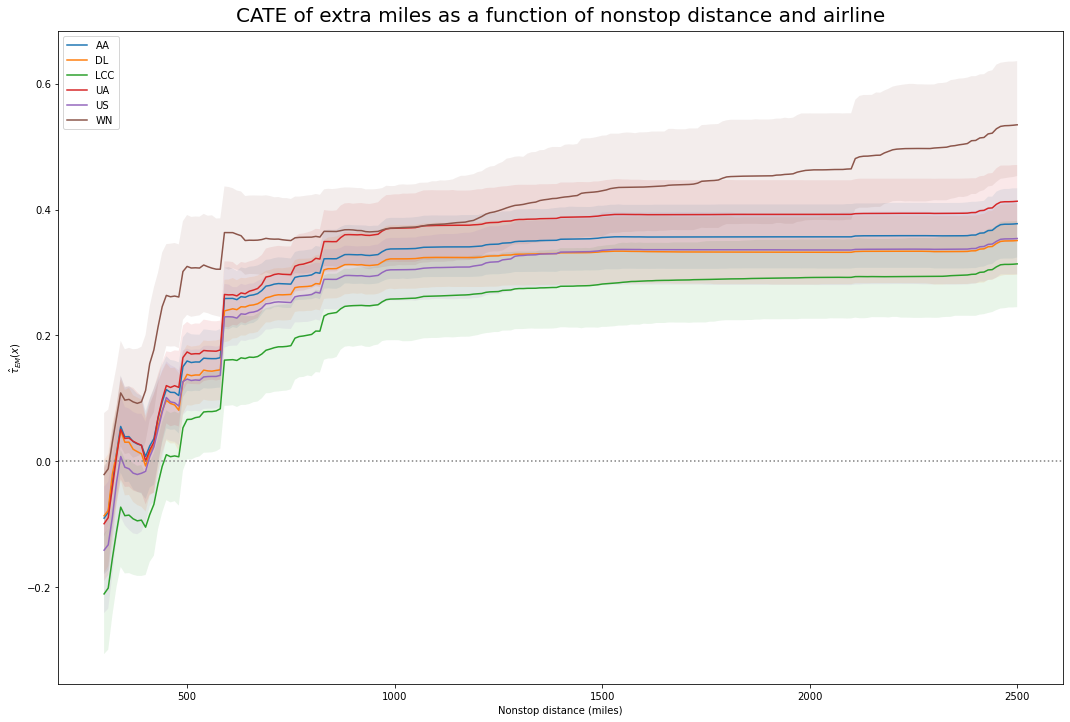

In [38]:
plt.plot(np.arange(300, 2501, 10),
         np.mean(AA_ests_grf, axis = 0), c = 'C0', label = 'AA')
plt.fill_between(np.arange(300, 2501, 10),
                 np.percentile(AA_ests_grf, 2.5, axis = 0).reshape(-1),
                 np.percentile(AA_ests_grf, 97.5, axis = 0).reshape(-1),
                 alpha = 0.1)
plt.plot(np.arange(300, 2501, 10),
         np.mean(DL_ests_grf, axis = 0), c = 'C1', label = 'DL')
plt.fill_between(np.arange(300, 2501, 10),
                 np.percentile(DL_ests_grf, 2.5, axis = 0).reshape(-1),
                 np.percentile(DL_ests_grf, 97.5, axis = 0).reshape(-1),
                 alpha = 0.1)
plt.plot(np.arange(300, 2501, 10),
         np.mean(LCC_ests_grf, axis = 0), c = 'C2', label = 'LCC')
plt.fill_between(np.arange(300, 2501, 10),
                 np.percentile(LCC_ests_grf, 2.5, axis = 0).reshape(-1),
                 np.percentile(LCC_ests_grf, 97.5, axis = 0).reshape(-1),
                 alpha = 0.1)
plt.plot(np.arange(300, 2501, 10),
         np.mean(UA_ests_grf, axis = 0), c = 'C3', label = 'UA')
plt.fill_between(np.arange(300, 2501, 10),
                 np.percentile(UA_ests_grf, 2.5, axis = 0).reshape(-1),
                 np.percentile(UA_ests_grf, 97.5, axis = 0).reshape(-1),
                 alpha = 0.1)
plt.plot(np.arange(300, 2501, 10),
         np.mean(US_ests_grf, axis = 0), c = 'C4', label = 'US')
plt.fill_between(np.arange(300, 2501, 10),
                 np.percentile(US_ests_grf, 2.5, axis = 0).reshape(-1),
                 np.percentile(US_ests_grf, 97.5, axis = 0).reshape(-1),
                 alpha = 0.1)
plt.plot(np.arange(300, 2501, 10),
         np.mean(WN_ests_grf, axis = 0), c = 'C5', label = 'WN')
plt.fill_between(np.arange(300, 2501, 10),
                 np.percentile(WN_ests_grf, 2.5, axis = 0).reshape(-1),
                 np.percentile(WN_ests_grf, 97.5, axis = 0).reshape(-1),
                 alpha = 0.1)
plt.axhline(0, color = 'grey', ls = 'dotted')
plt.xlabel('Nonstop distance (miles)')
plt.ylabel('$\hat{\\tau}_{EM}(x)$')
plt.title('CATE of extra miles as a function of nonstop distance and airline', fontsize = 20, pad = 10)
plt.legend(loc = 'upper left')

### Second step MLP marginal effects

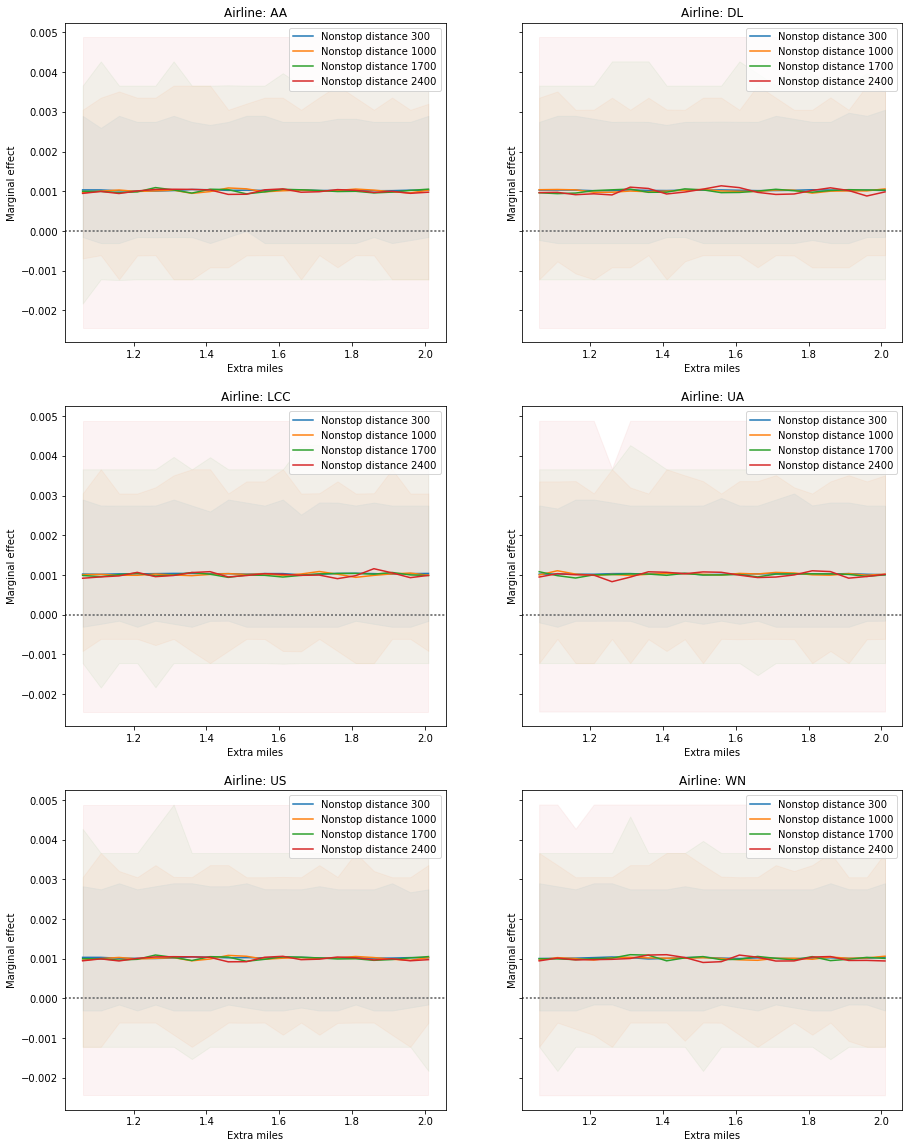

In [39]:
indices = [(i,j) for i in range(3) for j in range(2)]
fig, ax = plt.subplots(nrows = 3, ncols = 2, figsize = (15, 20), sharey = True)
for c,i in enumerate(np.arange(300,2401,700)):
    ax[indices[0]].plot(np.arange(1.01,2,0.05) + 0.05,
             np.mean(US_ests_mlp, axis = 0)[AA_grid1_mlp[:,3] == i].reshape(-1), c = f'C{c}', label = f'Nonstop distance {i}')
    ax[indices[0]].fill_between(np.arange(1.01,2,0.05) + 0.05,
                     np.percentile(AA_ests_mlp, 2.5, axis = 0)[AA_grid1_mlp[:,3] == i].reshape(-1),
                     np.percentile(AA_ests_mlp, 97.5, axis = 0)[AA_grid1_mlp[:,3] == i].reshape(-1),
                     alpha = 0.05, color = f'C{c}')
    ax[indices[0]].axhline(0, color = 'grey', ls = 'dotted')
    ax[indices[0]].legend()
    ax[indices[0]].set_title('Airline: AA')
    ax[indices[0]].set(xlabel = 'Extra miles', ylabel = 'Marginal effect')
    ax[indices[1]].plot(np.arange(1.01,2,0.05) + 0.05,
             np.mean(DL_ests_mlp, axis = 0)[DL_grid1_mlp[:,3] == i].reshape(-1), c = f'C{c}', label = f'Nonstop distance {i}')
    ax[indices[1]].fill_between(np.arange(1.01,2,0.05) + 0.05,
                     np.percentile(DL_ests_mlp, 2.5, axis = 0)[DL_grid1_mlp[:,3] == i].reshape(-1),
                     np.percentile(DL_ests_mlp, 97.5, axis = 0)[DL_grid1_mlp[:,3] == i].reshape(-1),
                     alpha = 0.05, color = f'C{c}')
    ax[indices[1]].axhline(0, color = 'grey', ls = 'dotted')
    ax[indices[1]].legend()
    ax[indices[1]].set_title('Airline: DL')
    ax[indices[1]].set(xlabel = 'Extra miles', ylabel = 'Marginal effect')
    ax[indices[2]].plot(np.arange(1.01,2,0.05) + 0.05,
             np.mean(LCC_ests_mlp, axis = 0)[LCC_grid1_mlp[:,3] == i].reshape(-1), c = f'C{c}', label = f'Nonstop distance {i}')
    ax[indices[2]].fill_between(np.arange(1.01,2,0.05) + 0.05,
                     np.percentile(LCC_ests_mlp, 2.5, axis = 0)[LCC_grid1_mlp[:,3] == i].reshape(-1),
                     np.percentile(LCC_ests_mlp, 97.5, axis = 0)[LCC_grid1_mlp[:,3] == i].reshape(-1),
                     alpha = 0.05, color = f'C{c}')
    ax[indices[2]].axhline(0, color = 'grey', ls = 'dotted')
    ax[indices[2]].legend()
    ax[indices[2]].set_title('Airline: LCC')
    ax[indices[2]].set(xlabel = 'Extra miles', ylabel = 'Marginal effect')
    ax[indices[3]].plot(np.arange(1.01,2,0.05) + 0.05,
             np.mean(UA_ests_mlp, axis = 0)[UA_grid1_mlp[:,3] == i].reshape(-1), c = f'C{c}', label = f'Nonstop distance {i}')
    ax[indices[3]].fill_between(np.arange(1.01,2,0.05) + 0.05,
                     np.percentile(UA_ests_mlp, 2.5, axis = 0)[UA_grid1_mlp[:,3] == i].reshape(-1),
                     np.percentile(UA_ests_mlp, 97.5, axis = 0)[UA_grid1_mlp[:,3] == i].reshape(-1),
                     alpha = 0.05, color = f'C{c}')
    ax[indices[3]].axhline(0, color = 'grey', ls = 'dotted')
    ax[indices[3]].legend()
    ax[indices[3]].set_title('Airline: UA')
    ax[indices[3]].set(xlabel = 'Extra miles', ylabel = 'Marginal effect')
    ax[indices[4]].plot(np.arange(1.01,2,0.05) + 0.05,
             np.mean(US_ests_mlp, axis = 0)[US_grid1_mlp[:,3] == i].reshape(-1), c = f'C{c}', label = f'Nonstop distance {i}')
    ax[indices[4]].fill_between(np.arange(1.01,2,0.05) + 0.05,
                     np.percentile(US_ests_mlp, 2.5, axis = 0)[US_grid1_mlp[:,3] == i].reshape(-1),
                     np.percentile(US_ests_mlp, 97.5, axis = 0)[US_grid1_mlp[:,3] == i].reshape(-1),
                     alpha = 0.05, color = f'C{c}')
    ax[indices[4]].axhline(0, color = 'grey', ls = 'dotted')
    ax[indices[4]].legend()
    ax[indices[4]].set_title('Airline: US')
    ax[indices[4]].set(xlabel = 'Extra miles', ylabel = 'Marginal effect')
    ax[indices[5]].plot(np.arange(1.01,2,0.05) + 0.05,
             np.mean(WN_ests_mlp, axis = 0)[WN_grid1_mlp[:,3] == i].reshape(-1), c = f'C{c}', label = f'Nonstop distance {i}')
    ax[indices[5]].fill_between(np.arange(1.01,2,0.05) + 0.05,
                     np.percentile(WN_ests_mlp, 2.5, axis = 0)[WN_grid1_mlp[:,3] == i].reshape(-1),
                     np.percentile(WN_ests_mlp, 97.5, axis = 0)[WN_grid1_mlp[:,3] == i].reshape(-1),
                     alpha = 0.05, color = f'C{c}')
    ax[indices[5]].axhline(0, color = 'grey', ls = 'dotted')
    ax[indices[5]].legend()
    ax[indices[5]].set_title('Airline: WN')
    ax[indices[5]].set(xlabel = 'Extra miles', ylabel = 'Marginal effect')